In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

# 1) Таймлайн перехода (последние события)
q = f"""
SELECT
    ts,
    event,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts DESC
LIMIT 50
"""
df_tl = ch_df(q).sort_values("ts")
print(df_tl.to_string(index=False))


In [1]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [1]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [2]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.{ORDERBOOK_TABLE}",
    f"{DB_NAME}.{PRICECHANGE_TABLE}",
    f"{DB_NAME}.ingest_heartbeat",
    f"{DB_NAME}.ingest_service_log",
]

for t in tables_to_truncate:
    print("TRUNCATE", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Done")


TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done


In [3]:
# %%
# Quick health checks
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""
)


,snapshots_cnt,total_orderbook_rows,rows_div_999
0,0,0,0.0


In [4]:
# %%
# Quick health checks
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""
)

,snapshots_cnt,total_orderbook_rows,rows_div_999
0,2,1998,2.0


In [5]:
q = f"""
SELECT
    ts,
    event,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts ASC
"""
print(ch_df(q).to_string(index=False))


                 ts                      event           status                                                             market                                                                      asset_id
2026-03-02 14:22:10  refresh_selection_changed       connecting 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11 orderbook_snapshot_written       subscribed 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11               ws_connected        connected 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11              ws_subscribed       subscribed 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 640725339386685491434466617386582

In [5]:
q = f"""
SELECT
    ts,
    event,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts ASC
"""
print(ch_df(q).to_string(index=False))


                 ts                      event           status                                                             market                                                                      asset_id
2026-03-02 14:22:10  refresh_selection_changed       connecting 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11 orderbook_snapshot_written       subscribed 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11               ws_connected        connected 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 64072533938668549143446661738658257692283170478278716248161697941329059597924
2026-03-02 14:22:11              ws_subscribed       subscribed 0x0d3948d75671e6ac1617a52cd5f3bcad1b6ce533c46d40200c889bcb43aa8c72 640725339386685491434466617386582

In [6]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.{ORDERBOOK_TABLE}",
    f"{DB_NAME}.{PRICECHANGE_TABLE}",
    f"{DB_NAME}.ingest_heartbeat",
    f"{DB_NAME}.ingest_service_log",
]

for t in tables_to_truncate:
    print("TRUNCATE", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Done")


TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done


In [7]:
# %%
# Quick health checks
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""

_IncompleteInputError: incomplete input (1450117438.py, line 10)

In [8]:
# %%
# Quick health checks
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""
)

,snapshots_cnt,total_orderbook_rows,rows_div_999
0,0,0,0.0


In [9]:
import pandas as pd

q = f"""
SELECT
    slot_start_msk,
    count() AS snapshots_cnt
FROM
(
    SELECT
        hash,
        toDateTime(intDiv(toUInt32(min(event_time_msk)), 900) * 900) AS slot_start_msk
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    GROUP BY market, asset_id, hash
)
GROUP BY slot_start_msk
ORDER BY slot_start_msk ASC
"""
df_slots = ch_df(q)
df_slots["slot_start_msk"] = pd.to_datetime(df_slots["slot_start_msk"])
df_slots["gap_min"] = df_slots["slot_start_msk"].diff().dt.total_seconds() / 60

print(df_slots.to_string(index=False))

bad_slots = df_slots[
    (df_slots["snapshots_cnt"] != 1) |
    ((df_slots["gap_min"].notna()) & (df_slots["gap_min"] != 15))
]
print("\nBAD_SLOTS:")
print(bad_slots.to_string(index=False) if not bad_slots.empty else "(empty)")


     slot_start_msk  snapshots_cnt  gap_min
2026-03-02 14:30:00              1      NaN
2026-03-02 14:45:00              1     15.0

BAD_SLOTS:
(empty)


In [10]:
q = f"""
SELECT
    market,
    asset_id,
    hash,
    min(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_time_msk DESC
LIMIT 2
"""
df_last2 = ch_df(q).sort_values("snapshot_time_msk").reset_index(drop=True)
print(df_last2.to_string(index=False))


                                                            market                                                                      asset_id                                     hash   snapshot_time_msk
0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1 67621028664607200942268826882939724021898983410575629300588448285664726007069 f0aefbc2a8c752435297896d56fee98c4579e690 2026-03-02 14:38:41
0x9e4e9e922fc8cba7d0b5ef7d8716f6a8e4cd9897af04e990b169908e9f9593d2 14121879208023388774433627388714530315224667526373962745127180889956215696585 cef4e16c5b635597cc5a8896ff0361d4195d1805 2026-03-02 14:45:01


In [11]:
old_market = df_last2.iloc[0]["market"]
old_asset = df_last2.iloc[0]["asset_id"]
new_market = df_last2.iloc[1]["market"]
new_asset = df_last2.iloc[1]["asset_id"]

q_old = f"""
SELECT
    max(event_time_msk) AS last_old_event_time,
    max(event_ts_ms) AS last_old_event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{old_market}'
  AND asset_id = '{old_asset}'
"""

q_new = f"""
SELECT
    min(event_time_msk) AS first_new_event_time,
    min(event_ts_ms) AS first_new_event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{new_market}'
  AND asset_id = '{new_asset}'
"""

df_old = ch_df(q_old)
df_new = ch_df(q_new)

last_old = pd.to_datetime(df_old.iloc[0]["last_old_event_time"])
first_new = pd.to_datetime(df_new.iloc[0]["first_new_event_time"])

gap_sec = (first_new - last_old).total_seconds()

print("old_market:", old_market)
print("new_market:", new_market)
print("last_old_event_time:", last_old)
print("first_new_event_time:", first_new)
print("gap_sec:", gap_sec)


old_market: 0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1
new_market: 0x9e4e9e922fc8cba7d0b5ef7d8716f6a8e4cd9897af04e990b169908e9f9593d2
last_old_event_time: 2026-03-02 14:44:29
first_new_event_time: 2026-03-02 14:45:01
gap_sec: 32.0


In [12]:
# возьмем последний рынок
q = f"""
SELECT
    market,
    asset_id
FROM {DB_NAME}.{PRICECHANGE_TABLE}
GROUP BY market, asset_id
ORDER BY max(event_ts_ms) DESC
LIMIT 1
"""
df_ctx = ch_df(q)

market = df_ctx.iloc[0]["market"]
asset_id = df_ctx.iloc[0]["asset_id"]

q = f"""
SELECT
    event_ts_ms,
    event_time_msk,
    ingest_time,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
ORDER BY event_ts_ms ASC, price ASC
"""
df_pc = ch_df(q)
df_pc["gap_ms"] = df_pc["event_ts_ms"].diff()

# Покажем только подозрительные разрывы > 3000 мс
df_gaps = df_pc[df_pc["gap_ms"] > 3000].copy()

print("market:", market)
print("asset_id:", asset_id)
print("rows_total:", len(df_pc))
print("\nSUSPICIOUS_GAPS (>3000 ms):")
print(df_gaps[["event_time_msk", "ingest_time", "event_ts_ms", "gap_ms", "side", "price", "size"]].to_string(index=False) if not df_gaps.empty else "(empty)")


market: 0x9e4e9e922fc8cba7d0b5ef7d8716f6a8e4cd9897af04e990b169908e9f9593d2
asset_id: 14121879208023388774433627388714530315224667526373962745127180889956215696585
rows_total: 22518

SUSPICIOUS_GAPS (>3000 ms):
     event_time_msk         ingest_time   event_ts_ms  gap_ms side  price   size
2026-03-02 14:46:44 2026-03-02 14:46:44 1772452004745 56069.0  ask   0.81 192.58
2026-03-02 14:47:12 2026-03-02 14:47:12 1772452032807 17098.0  ask   0.77 531.45
2026-03-02 14:48:37 2026-03-02 14:48:37 1772452117751 53906.0  bid   0.48   9.40


In [1]:
q = f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  round(sum(size), 3) AS total_size,
  sum(if(size < 0, 1, 0)) AS negative_size_rows,
  sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_range_rows,
  sum(if(abs(price * 1000 - round(price * 1000)) > 1e-9, 1, 0)) AS bad_grid_rows
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
df_ob = ch_df(q)
print(df_ob.to_string(index=False))


NameError: name 'DB_NAME' is not defined

In [2]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


In [3]:
q = f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  round(sum(size), 3) AS total_size,
  sum(if(size < 0, 1, 0)) AS negative_size_rows,
  sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_range_rows,
  sum(if(abs(price * 1000 - round(price * 1000)) > 1e-9, 1, 0)) AS bad_grid_rows
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
df_ob = ch_df(q)
print(df_ob.to_string(index=False))


                                                            market                                                                      asset_id                                     hash   snapshot_time_msk  snapshot_ts_ms  levels  non_zero_levels  total_size  negative_size_rows  bad_price_range_rows  bad_grid_rows
0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109 67549324874022105694499727647528634715042676720366908882990084026992146305705 65bf1ae27386e627c5c7dde84727949ce74f7082 2026-03-02 22:45:18   1772480718533     999               99   118627.78                   0                     0              0
0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3 29891709321733542309251713964207212086391082054561156726047402815033078161433 706f03b7fd28f96e2bfa6ef6bf09ef41524df211 2026-03-02 22:30:14   1772479814331     999               97   113980.40                   0                     0              0
0xa6c6254781b7e0551998119d0e8dfb25b928c3bfa6ec6bd7ba

In [4]:
target_markets = [
    "0x9e4e9e922fc8cba7d0b5ef7d8716f6a8e4cd9897af04e990b169908e9f9593d2",
    "0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1",
]

markets_sql = ", ".join(f"'{m}'" for m in target_markets)

ch_cmd(f"""
ALTER TABLE {DB_NAME}.{ORDERBOOK_TABLE}
DELETE WHERE market IN ({markets_sql})
""")

ch_cmd(f"""
ALTER TABLE {DB_NAME}.{PRICECHANGE_TABLE}
DELETE WHERE market IN ({markets_sql})
""")

print("Delete mutations submitted")


Delete mutations submitted


In [5]:
q = f"""
SELECT
  '{ORDERBOOK_TABLE}' AS table_name,
  count() AS rows_left
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market IN ({markets_sql})

UNION ALL

SELECT
  '{PRICECHANGE_TABLE}' AS table_name,
  count() AS rows_left
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market IN ({markets_sql})
"""
ch_df(q)


,table_name,rows_left
0,orderbook,0
1,pricechange,0


In [6]:
q = f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  round(sum(size), 3) AS total_size,
  sum(if(size < 0, 1, 0)) AS negative_size_rows,
  sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_range_rows,
  sum(if(abs(price * 1000 - round(price * 1000)) > 1e-9, 1, 0)) AS bad_grid_rows
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
df_ob = ch_df(q)
print(df_ob.to_string(index=False))

                                                            market                                                                      asset_id                                     hash   snapshot_time_msk  snapshot_ts_ms  levels  non_zero_levels  total_size  negative_size_rows  bad_price_range_rows  bad_grid_rows
0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109 67549324874022105694499727647528634715042676720366908882990084026992146305705 65bf1ae27386e627c5c7dde84727949ce74f7082 2026-03-02 22:45:18   1772480718533     999               99   118627.78                   0                     0              0
0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3 29891709321733542309251713964207212086391082054561156726047402815033078161433 706f03b7fd28f96e2bfa6ef6bf09ef41524df211 2026-03-02 22:30:14   1772479814331     999               97   113980.40                   0                     0              0
0xa6c6254781b7e0551998119d0e8dfb25b928c3bfa6ec6bd7ba

In [7]:
q = f"""
SELECT
    check_name,
    value_num,
    details
FROM
(
    SELECT
        'orderbook_rows' AS check_name,
        toFloat64(count()) AS value_num,
        '' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}

    UNION ALL

    SELECT
        'pricechange_rows' AS check_name,
        toFloat64(count()) AS value_num,
        '' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}

    UNION ALL

    SELECT
        'snapshots_cnt' AS check_name,
        toFloat64(countDistinct(concat(market, '|', asset_id, '|', hash))) AS value_num,
        '' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}

    UNION ALL

    SELECT
        'orderbook_expected_rows_from_snapshots' AS check_name,
        toFloat64(countDistinct(concat(market, '|', asset_id, '|', hash)) * 999) AS value_num,
        'should equal orderbook_rows' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}

    UNION ALL

    SELECT
        'bad_snapshots_cnt' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM
    (
        SELECT
            market,
            asset_id,
            hash
        FROM {DB_NAME}.{ORDERBOOK_TABLE}
        GROUP BY market, asset_id, hash
        HAVING count() != 999
           OR sum(if(size > 0, 1, 0)) = 0
           OR sum(size) <= 0
    )

    UNION ALL

    SELECT
        'orderbook_negative_size_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    WHERE size < 0

    UNION ALL

    SELECT
        'orderbook_bad_price_range_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    WHERE price < 0.001 OR price > 0.999

    UNION ALL

    SELECT
        'orderbook_bad_grid_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    WHERE abs(price * 1000 - round(price * 1000)) > 0.000000001

    UNION ALL

    SELECT
        'orderbook_duplicate_level_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM
    (
        SELECT
            market,
            asset_id,
            hash,
            side,
            price
        FROM {DB_NAME}.{ORDERBOOK_TABLE}
        GROUP BY market, asset_id, hash, side, price
        HAVING count() > 1
    )

    UNION ALL

    SELECT
        'pricechange_zero_delta_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE size = 0

    UNION ALL

    SELECT
        'pricechange_bad_side_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE side NOT IN ('bid', 'ask')

    UNION ALL

    SELECT
        'pricechange_bad_price_range_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE price < 0.001 OR price > 0.999

    UNION ALL

    SELECT
        'pricechange_bad_grid_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE abs(price * 1000 - round(price * 1000)) > 0.000000001

    UNION ALL

    SELECT
        'pricechange_duplicate_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM
    (
        SELECT
            market,
            asset_id,
            event_ts_ms,
            hash,
            side,
            price
        FROM {DB_NAME}.{PRICECHANGE_TABLE}
        GROUP BY market, asset_id, event_ts_ms, hash, side, price
        HAVING count() > 1
    )

    UNION ALL

    SELECT
        'pricechange_orphan_market_asset_pairs' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM
    (
        SELECT
            pc.market,
            pc.asset_id
        FROM
        (
            SELECT
                market,
                asset_id,
                min(event_ts_ms) AS first_pc_ts
            FROM {DB_NAME}.{PRICECHANGE_TABLE}
            GROUP BY market, asset_id
        ) pc
        LEFT JOIN
        (
            SELECT
                market,
                asset_id,
                min(event_ts_ms) AS first_ob_ts
            FROM {DB_NAME}.{ORDERBOOK_TABLE}
            GROUP BY market, asset_id
        ) ob
        ON pc.market = ob.market AND pc.asset_id = ob.asset_id
        WHERE ob.first_ob_ts IS NULL OR pc.first_pc_ts < ob.first_ob_ts
    )

    UNION ALL

    SELECT
        'pricechange_avg_lag_ms' AS check_name,
        round(avg(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms), 2) AS value_num,
        'informational' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}

    UNION ALL

    SELECT
        'pricechange_max_lag_ms' AS check_name,
        toFloat64(max(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms)) AS value_num,
        'informational' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}

    UNION ALL

    SELECT
        'pricechange_lag_gt_10s_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'should be low' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE (toUnixTimestamp(ingest_time) * 1000 - event_ts_ms) > 10000

    UNION ALL

    SELECT
        'deleted_markets_rows_left_in_orderbook' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    WHERE market IN ({markets_sql})

    UNION ALL

    SELECT
        'deleted_markets_rows_left_in_pricechange' AS check_name,
        toFloat64(count()) AS value_num,
        'must be 0' AS details
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    WHERE market IN ({markets_sql})

    UNION ALL

    SELECT
        'service_error_rows' AS check_name,
        toFloat64(count()) AS value_num,
        'should be 0' AS details
    FROM {DB_NAME}.ingest_service_log
    WHERE level = 'ERROR' OR error_text != ''
)
ORDER BY check_name
"""
df_qc = ch_df(q)
print(df_qc.to_string(index=False))

                              check_name   value_num                     details
                       bad_snapshots_cnt        0.00                   must be 0
  deleted_markets_rows_left_in_orderbook        0.00                   must be 0
deleted_markets_rows_left_in_pricechange        0.00                   must be 0
                 orderbook_bad_grid_rows        0.00                   must be 0
          orderbook_bad_price_range_rows        0.00                   must be 0
          orderbook_duplicate_level_rows        0.00                   must be 0
  orderbook_expected_rows_from_snapshots     2997.00 should equal orderbook_rows
            orderbook_negative_size_rows        0.00                   must be 0
                          orderbook_rows     2997.00                            
                  pricechange_avg_lag_ms 10800563.26               informational
               pricechange_bad_grid_rows        0.00                   must be 0
        pricechange_bad_pric

In [8]:
q = f"""
SELECT
    ts,
    event,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts ASC
"""
print(ch_df(q).to_string(index=False))

                 ts                      event           status                                                             market                                                                      asset_id
2026-03-02 14:38:40               ws_connected        connected 0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1 67621028664607200942268826882939724021898983410575629300588448285664726007069
2026-03-02 14:38:40  refresh_selection_changed       connecting 0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1 67621028664607200942268826882939724021898983410575629300588448285664726007069
2026-03-02 14:38:40              ws_subscribed       subscribed 0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1 67621028664607200942268826882939724021898983410575629300588448285664726007069
2026-03-02 14:38:41 orderbook_snapshot_written       subscribed 0x02ec12657f8440445ff785997e67871dc05a01cbcdbddf22c5a1159b82d81eb1 676210286646072009422688268829397

In [9]:
market = "0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109"
n = 100.0  # твой порог size

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")


NameError: name 'build_depth_filtered_best_quotes_df' is not defined

In [10]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [11]:
market = "0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109"
n = 100.0  # твой порог size

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")

NameError: name 'build_depth_filtered_best_quotes_df' is not defined

In [12]:
# %%
# Quick health checks
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""
)

,snapshots_cnt,total_orderbook_rows,rows_div_999
0,3,2997,3.0


In [13]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _depth_price(level_sizes: dict, ordered_prices: list, min_total_size: float):
    total_size = 0.0
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size <= 0:
            continue
        total_size += size
        if total_size + 1e-12 >= float(min_total_size):
            return float(price), float(total_size)
    return float("nan"), float(total_size)


def build_depth_filtered_best_quotes_df(
    market: str,
    min_total_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return depth-filtered best bid/ask.

    The returned price is the marginal executable level where cumulative size first
    reaches `min_total_size`:
    - bid: start from best bid, then 0.001 lower, etc.
    - ask: start from best ask, then 0.001 higher, etc.

    If there are multiple snapshots for the same market, the latest one is used by
    default. Pass `snapshot_hash` to pin a specific snapshot segment.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
            best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "n": float(min_total_size),
                    "best_bid_n": best_bid_n,
                    "best_ask_n": best_ask_n,
                    "cum_bid_size_at_best_bid_n": cum_bid_size,
                    "cum_ask_size_at_best_ask_n": cum_ask_size,
                    "spread_n": best_ask_n - best_bid_n
                    if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)

,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n
32222,2026-03-02 22:47:53,1772480873430,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,100.0,0.74,0.75,162.56,472.05,0.01
32223,2026-03-02 22:47:53,1772480873432,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,100.0,0.74,0.75,162.56,472.05,0.01
32224,2026-03-02 22:47:53,1772480873434,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,100.0,0.74,0.75,162.56,472.05,0.01
32225,2026-03-02 22:47:53,1772480873451,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,100.0,0.74,0.75,162.56,472.05,0.01
32226,2026-03-02 22:47:53,1772480873452,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,100.0,0.74,0.75,162.56,132.05,0.01


Text(0, 0.5, 'price')

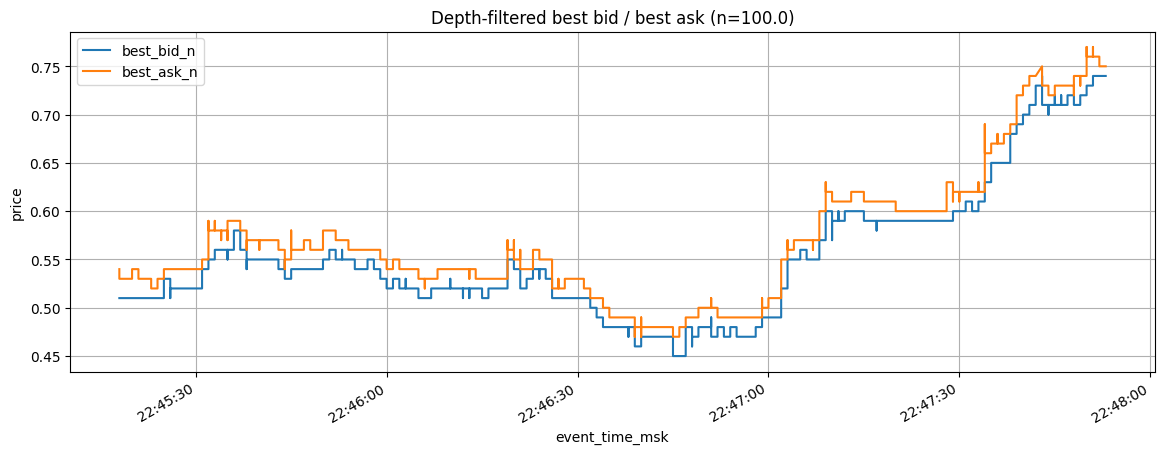

In [14]:
market = "0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109"
n = 100.0

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n
32222,2026-03-02 22:47:53,1772480873430,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,50.0,0.74,0.75,162.56,472.05,0.01
32223,2026-03-02 22:47:53,1772480873432,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,50.0,0.74,0.75,162.56,472.05,0.01
32224,2026-03-02 22:47:53,1772480873434,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,50.0,0.74,0.75,162.56,472.05,0.01
32225,2026-03-02 22:47:53,1772480873451,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,50.0,0.74,0.75,162.56,472.05,0.01
32226,2026-03-02 22:47:53,1772480873452,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b291...,6754932487402210569449972764752863471504267672...,65bf1ae27386e627c5c7dde84727949ce74f7082,50.0,0.74,0.75,162.56,132.05,0.01


Text(0, 0.5, 'price')

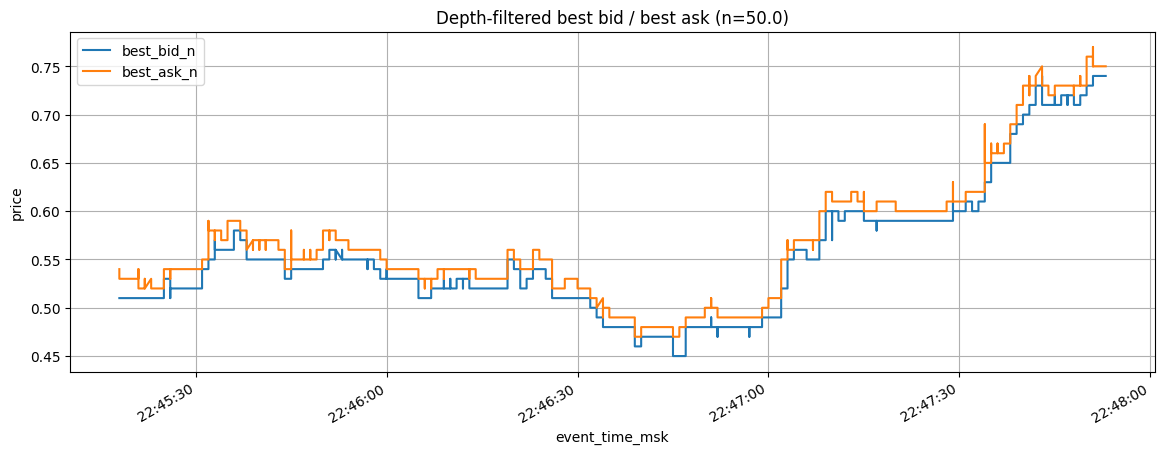

In [15]:
market = "0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109"
n = 50.0

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")

In [16]:
ch_df(f"""
SELECT
    min(event_time_msk) AS min_time,
    max(event_time_msk) AS max_time,
    count() AS rows
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
""")


,min_time,max_time,rows
0,2026-03-02 22:45:18,2026-03-02 22:47:53,33855


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN


Text(0, 0.5, 'price')

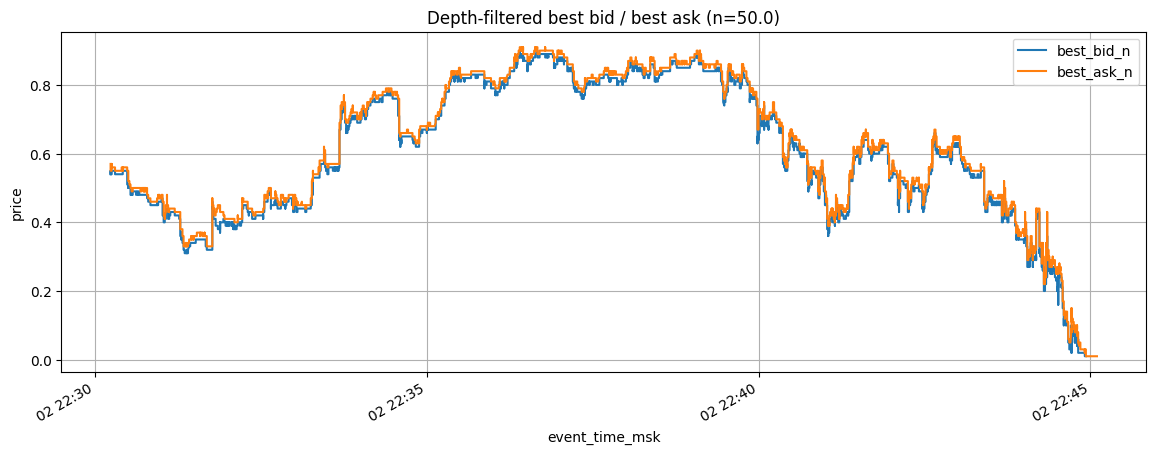

In [17]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
n = 50.0

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")

In [18]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
n = 0

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")

ValueError: min_total_size must be > 0

,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.1,0.23,0.01,11.0,728511.82,-0.22
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.1,0.23,0.01,11.0,728511.82,-0.22
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.1,0.23,0.01,11.0,728517.89,-0.22
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.1,0.23,0.01,11.0,728517.89,-0.22
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.1,0.23,0.01,11.0,728517.89,-0.22


Text(0, 0.5, 'price')

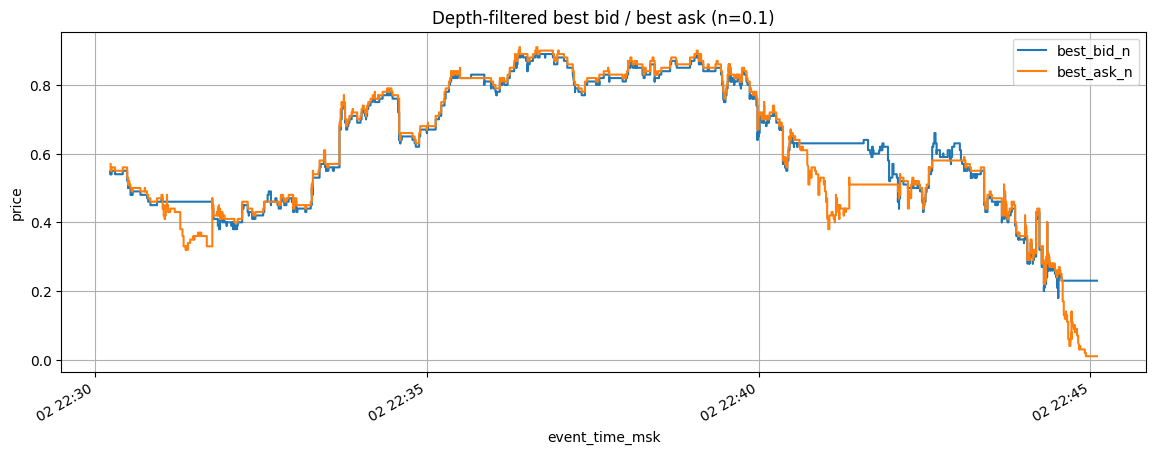

In [19]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
n = 0.1

df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=n,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_n", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Depth-filtered best bid / best ask (n={n})",
)
ax.set_ylabel("price")

In [20]:
def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _best_price(level_sizes: dict, ordered_prices: list):
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size > 0:
            return float(price), float(size)
    return float("nan"), 0.0


def build_best_quotes_df(
    market: str,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return plain best bid / best ask
    (without depth threshold n).

    - best_bid: highest bid price with size > 0
    - best_ask: lowest ask price with size > 0
    """
    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid, best_bid_size = _best_price(bid_sizes, bid_prices_desc)
        best_ask, best_ask_size = _best_price(ask_sizes, ask_prices_asc)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "best_bid": best_bid,
                "best_ask": best_ask,
                "best_bid_size": best_bid_size,
                "best_ask_size": best_ask_size,
                "spread": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid, best_bid_size = _best_price(bid_sizes, bid_prices_desc)
            best_ask, best_ask_size = _best_price(ask_sizes, ask_prices_asc)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "best_bid": best_bid,
                    "best_ask": best_ask,
                    "best_bid_size": best_bid_size,
                    "best_ask_size": best_ask_size,
                    "spread": best_ask - best_bid
                    if pd.notna(best_bid) and pd.notna(best_ask)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid, best_bid_size = _best_price(bid_sizes, bid_prices_desc)
        best_ask, best_ask_size = _best_price(ask_sizes, ask_prices_asc)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "best_bid": best_bid,
                "best_ask": best_ask,
                "best_bid_size": best_bid_size,
                "best_ask_size": best_ask_size,
                "spread": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,best_bid,best_ask,best_bid_size,best_ask_size,spread
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.81,0.01,2.273737e-12,728511.82,-0.8
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.81,0.01,2.273737e-12,728511.82,-0.8
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.81,0.01,2.273737e-12,728517.89,-0.8
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.81,0.01,2.273737e-12,728517.89,-0.8
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d5...,2989170932173354230925171396420721208639108205...,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,0.81,0.01,2.273737e-12,728517.89,-0.8


Text(0, 0.5, 'price')

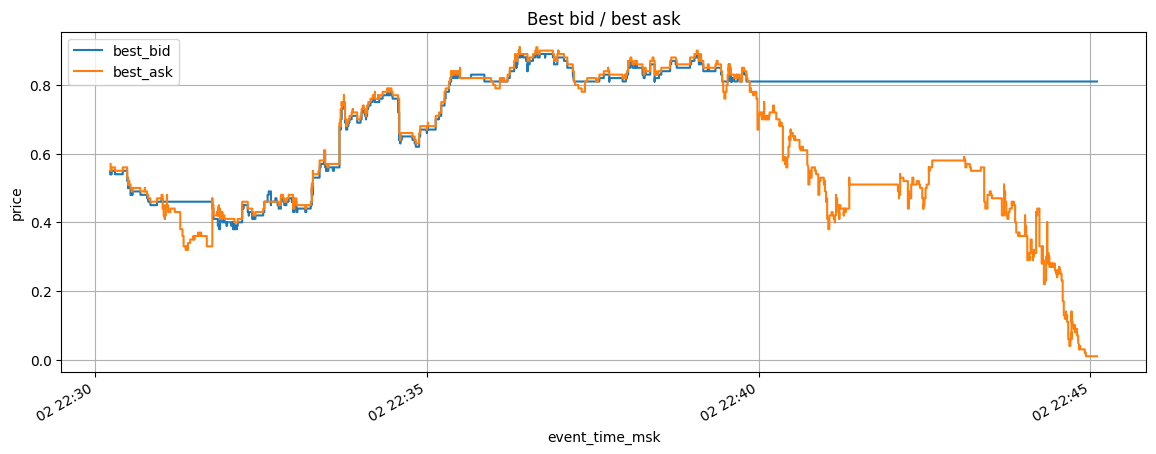

In [21]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

df_quotes = build_best_quotes_df(market=market)
display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid", "best_ask"],
    figsize=(14, 5),
    grid=True,
    title="Best bid / best ask",
)
ax.set_ylabel("price")


In [22]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _depth_price(level_sizes: dict, ordered_prices: list, min_total_size: float):
    total_size = 0.0
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size <= 0:
            continue
        total_size += size
        if total_size + 1e-12 >= float(min_total_size):
            return float(price), float(total_size)
    return float("nan"), float(total_size)


def _best_price_with_min_level(level_sizes: dict, ordered_prices: list, min_level_size: float):
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size + 1e-12 >= float(min_level_size):
            return float(price), float(size)
    return float("nan"), 0.0


def build_best_quotes_min_level_df(
    market: str,
    min_level_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return best bid/ask with
    a per-level size floor.

    - best_bid: highest bid price with size >= min_level_size
    - best_ask: lowest ask price with size >= min_level_size

    This is a cleaner alternative to raw top-of-book when tiny residual sizes
    create noisy or crossed quotes.
    """
    if float(min_level_size) <= 0:
        raise ValueError("min_level_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid, best_bid_size = _best_price_with_min_level(bid_sizes, bid_prices_desc, min_level_size)
        best_ask, best_ask_size = _best_price_with_min_level(ask_sizes, ask_prices_asc, min_level_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "min_level_size": float(min_level_size),
                "best_bid_filtered": best_bid,
                "best_ask_filtered": best_ask,
                "best_bid_level_size": best_bid_size,
                "best_ask_level_size": best_ask_size,
                "spread_filtered": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid, best_bid_size = _best_price_with_min_level(
                bid_sizes, bid_prices_desc, min_level_size
            )
            best_ask, best_ask_size = _best_price_with_min_level(
                ask_sizes, ask_prices_asc, min_level_size
            )
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "min_level_size": float(min_level_size),
                    "best_bid_filtered": best_bid,
                    "best_ask_filtered": best_ask,
                    "best_bid_level_size": best_bid_size,
                    "best_ask_level_size": best_ask_size,
                    "spread_filtered": best_ask - best_bid
                    if pd.notna(best_bid) and pd.notna(best_ask)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid, best_bid_size = _best_price_with_min_level(bid_sizes, bid_prices_desc, min_level_size)
        best_ask, best_ask_size = _best_price_with_min_level(ask_sizes, ask_prices_asc, min_level_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "min_level_size": float(min_level_size),
                "best_bid_filtered": best_bid,
                "best_ask_filtered": best_ask,
                "best_bid_level_size": best_bid_size,
                "best_ask_level_size": best_ask_size,
                "spread_filtered": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


def build_depth_filtered_best_quotes_df(
    market: str,
    min_total_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return depth-filtered best bid/ask.

    The returned price is the marginal executable level where cumulative size first
    reaches `min_total_size`:
    - bid: start from best bid, then 0.001 lower, etc.
    - ask: start from best ask, then 0.001 higher, etc.

    If there are multiple snapshots for the same market, the latest one is used by
    default. Pass `snapshot_hash` to pin a specific snapshot segment.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
            best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "n": float(min_total_size),
                    "best_bid_n": best_bid_n,
                    "best_ask_n": best_ask_n,
                    "cum_bid_size_at_best_bid_n": cum_bid_size,
                    "cum_ask_size_at_best_ask_n": cum_ask_size,
                    "spread_n": best_ask_n - best_bid_n
                    if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,10.0,0.23,0.01,11.0,728511.82,-0.22
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,10.0,0.23,0.01,11.0,728511.82,-0.22
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,10.0,0.23,0.01,11.0,728517.89,-0.22
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,10.0,0.23,0.01,11.0,728517.89,-0.22
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,10.0,0.23,0.01,11.0,728517.89,-0.22


Text(0, 0.5, 'price')

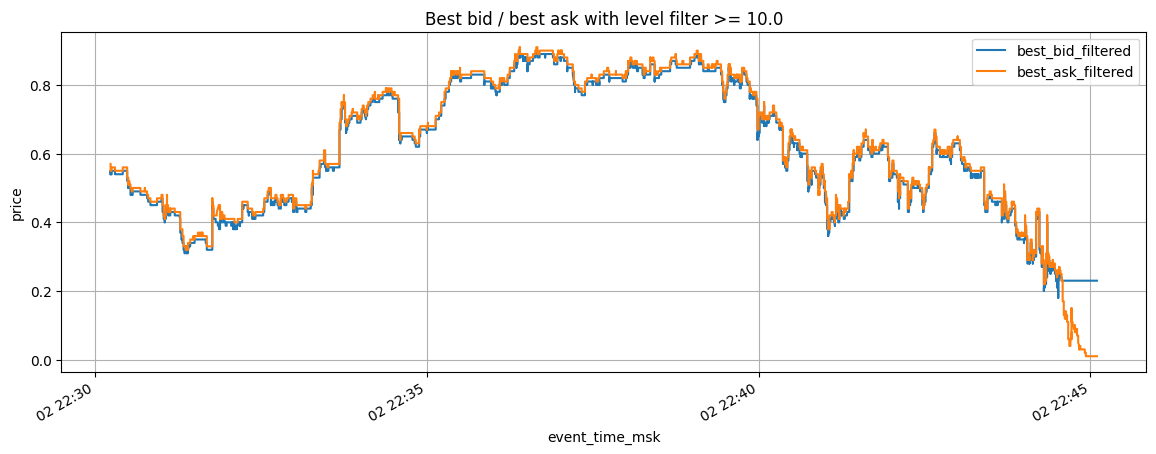

In [23]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 5.0  # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,5.0,0.23,0.01,11.0,728511.82,-0.22
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,5.0,0.23,0.01,11.0,728511.82,-0.22
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,5.0,0.23,0.01,11.0,728517.89,-0.22
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,5.0,0.23,0.01,11.0,728517.89,-0.22
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,5.0,0.23,0.01,11.0,728517.89,-0.22


Text(0, 0.5, 'price')

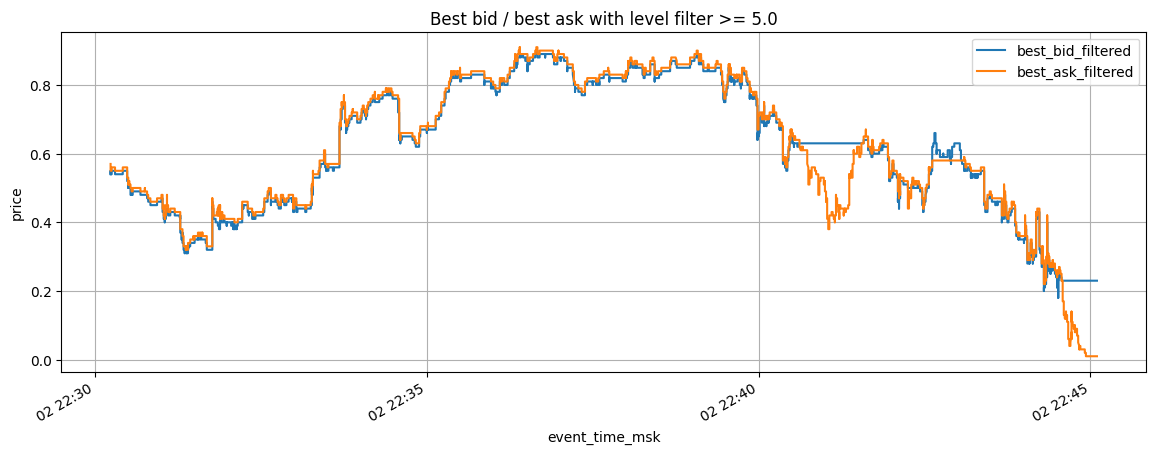

In [24]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 5.0  # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,1.0,0.23,0.01,11.0,728511.82,-0.22
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,1.0,0.23,0.01,11.0,728511.82,-0.22
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,1.0,0.23,0.01,11.0,728517.89,-0.22
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,1.0,0.23,0.01,11.0,728517.89,-0.22
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,1.0,0.23,0.01,11.0,728517.89,-0.22


Text(0, 0.5, 'price')

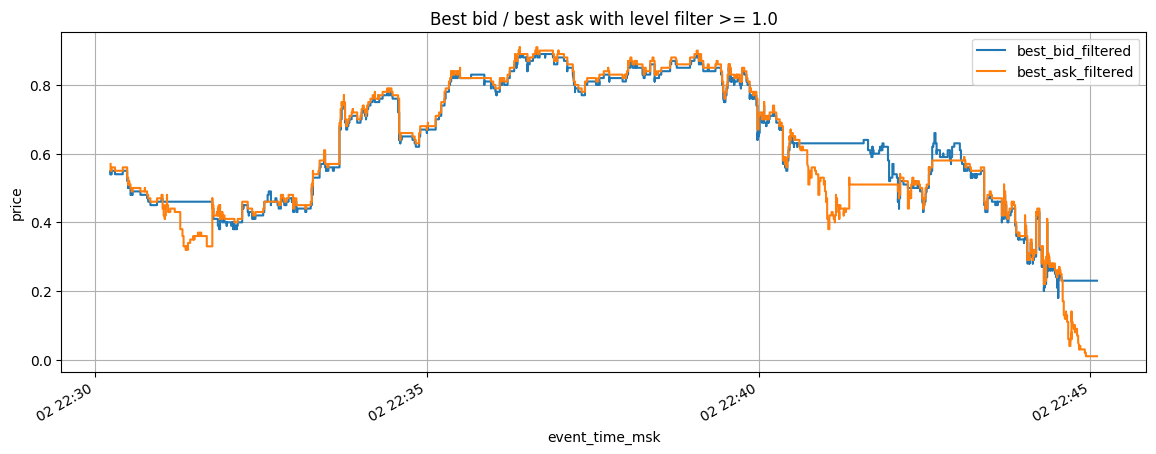

In [25]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 1.0  # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728511.82,NaN
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728511.82,NaN
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN


Text(0, 0.5, 'price')

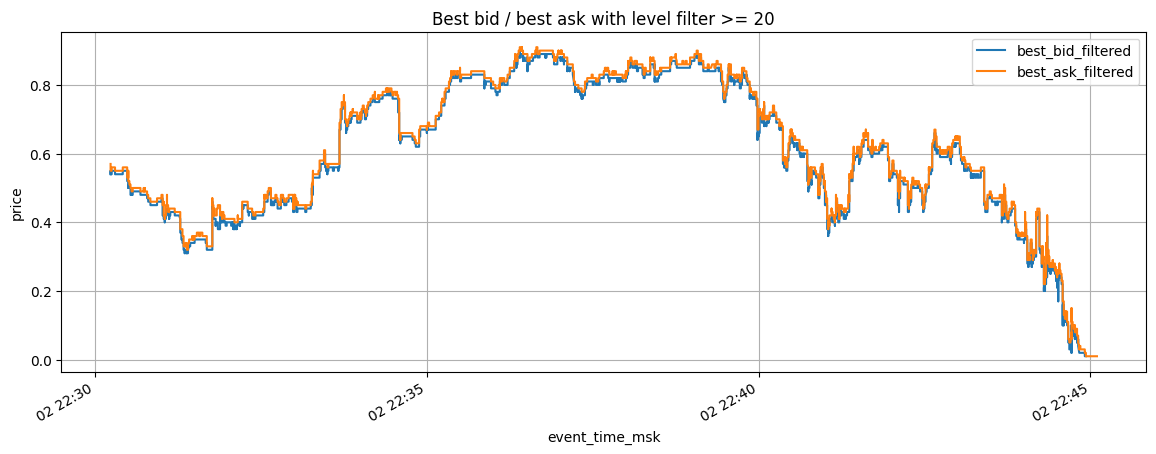

In [26]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 20 # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,200.0,NaN,0.01,0.0,728511.82,NaN
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,200.0,NaN,0.01,0.0,728511.82,NaN
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,200.0,NaN,0.01,0.0,728517.89,NaN
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,200.0,NaN,0.01,0.0,728517.89,NaN
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,200.0,NaN,0.01,0.0,728517.89,NaN


Text(0, 0.5, 'price')

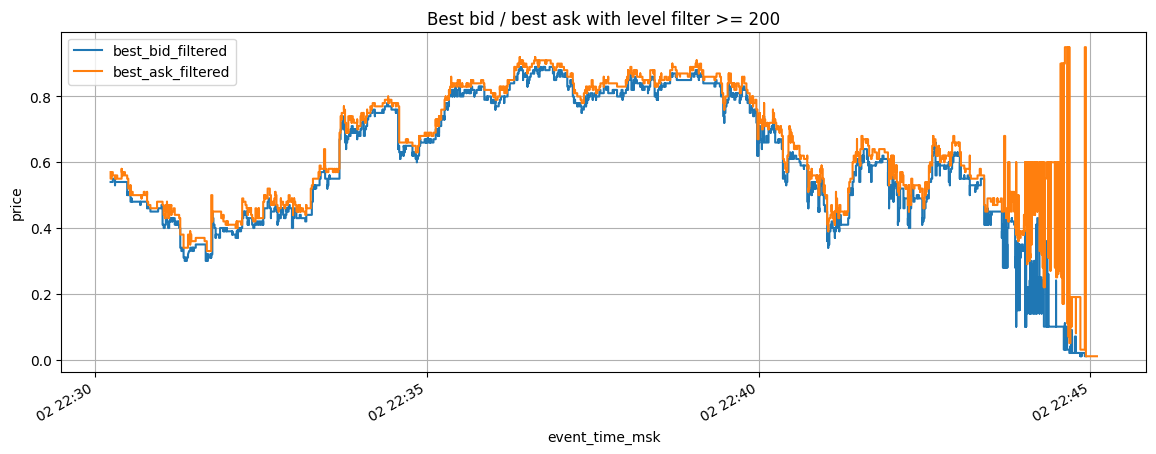

In [27]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 200 # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")

In [28]:
def build_theoretical_up_price_df(
    market: str,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
    asset_id: str = None,
    snapshot_hash: str = None,
) -> pd.DataFrame:
    """
    Build a practical theoretical-price proxy for the UP contract.

    The mechanism is:
    1) reconstruct depth-filtered bid/ask via cumulative depth `min_total_size`
    2) compute depth-filtered microprice
    3) smooth that microprice with an exponential moving average

    This is a microstructure-based fair value proxy, not a BTC spot/vol model.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")
    if int(ewm_span) <= 1:
        raise ValueError("ewm_span must be > 1")

    df = build_depth_filtered_best_quotes_df(
        market=market,
        min_total_size=min_total_size,
        asset_id=asset_id,
        snapshot_hash=snapshot_hash,
    ).copy()

    if df.empty:
        return df

    df = df.sort_values(["event_ts_ms", "event_time_msk"]).reset_index(drop=True)

    df["mid_n"] = (df["best_bid_n"] + df["best_ask_n"]) / 2.0

    denom = df["cum_bid_size_at_best_bid_n"] + df["cum_ask_size_at_best_ask_n"]
    df["microprice_n"] = df["mid_n"]
    good = denom > 0
    df.loc[good, "microprice_n"] = (
        df.loc[good, "best_ask_n"] * df.loc[good, "cum_bid_size_at_best_bid_n"]
        + df.loc[good, "best_bid_n"] * df.loc[good, "cum_ask_size_at_best_ask_n"]
    ) / denom.loc[good]

    df["theoretical_up_raw"] = df["microprice_n"]
    df["theoretical_up"] = (
        df["theoretical_up_raw"]
        .ewm(span=int(ewm_span), adjust=False, min_periods=1)
        .mean()
    )

    df["gap_to_bid_n"] = df["theoretical_up"] - df["best_bid_n"]
    df["gap_to_ask_n"] = df["best_ask_n"] - df["theoretical_up"]
    df["abs_gap_to_mid_n"] = (df["theoretical_up"] - df["mid_n"]).abs()

    # Positive value means the theoretical price is outside the current quote
    # and indicates a potential directional edge.
    df["buy_edge_vs_ask_n"] = df["theoretical_up"] - df["best_ask_n"]
    df["sell_edge_vs_bid_n"] = df["best_bid_n"] - df["theoretical_up"]
    df["max_cross_side_edge_n"] = df[["buy_edge_vs_ask_n", "sell_edge_vs_bid_n"]].max(axis=1)

    return df


def rank_markets_by_theoretical_gap(
    markets,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
) -> pd.DataFrame:
    """
    Rank markets by how strongly their quoted prices diverge from the
    theoretical UP price proxy.

    Output metrics:
    - max_abs_gap_to_mid_n: largest |theoretical_up - mid_n|
    - p95_abs_gap_to_mid_n: 95th percentile of that gap
    - max_buy_edge_vs_ask_n: strongest positive buy edge vs ask
    - max_sell_edge_vs_bid_n: strongest positive sell edge vs bid
    - max_cross_side_edge_n: strongest quote dislocation on either side
    """
    rows = []

    for market in markets:
        try:
            df = build_theoretical_up_price_df(
                market=market,
                min_total_size=min_total_size,
                ewm_span=ewm_span,
            )

            if df.empty:
                rows.append(
                    {
                        "market": market,
                        "rows": 0,
                        "max_abs_gap_to_mid_n": float("nan"),
                        "p95_abs_gap_to_mid_n": float("nan"),
                        "max_buy_edge_vs_ask_n": float("nan"),
                        "max_sell_edge_vs_bid_n": float("nan"),
                        "max_cross_side_edge_n": float("nan"),
                        "last_theoretical_up": float("nan"),
                        "last_best_bid_n": float("nan"),
                        "last_best_ask_n": float("nan"),
                    }
                )
                continue

            last = df.iloc[-1]
            rows.append(
                {
                    "market": market,
                    "rows": int(len(df)),
                    "max_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].max()),
                    "p95_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].quantile(0.95)),
                    "max_buy_edge_vs_ask_n": float(df["buy_edge_vs_ask_n"].max()),
                    "max_sell_edge_vs_bid_n": float(df["sell_edge_vs_bid_n"].max()),
                    "max_cross_side_edge_n": float(df["max_cross_side_edge_n"].max()),
                    "last_theoretical_up": float(last["theoretical_up"]),
                    "last_best_bid_n": float(last["best_bid_n"]),
                    "last_best_ask_n": float(last["best_ask_n"]),
                }
            )
        except Exception as e:
            rows.append(
                {
                    "market": market,
                    "rows": 0,
                    "max_abs_gap_to_mid_n": float("nan"),
                    "p95_abs_gap_to_mid_n": float("nan"),
                    "max_buy_edge_vs_ask_n": float("nan"),
                    "max_sell_edge_vs_bid_n": float("nan"),
                    "max_cross_side_edge_n": float("nan"),
                    "last_theoretical_up": float("nan"),
                    "last_best_bid_n": float("nan"),
                    "last_best_ask_n": float("nan"),
                    "error": repr(e),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    return out.sort_values(
        ["max_cross_side_edge_n", "p95_abs_gap_to_mid_n"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

In [29]:
# 2) Выбрать рынки для сравнения
markets = df_markets["market"].tolist()   # или вручную только нужные 2 market id
markets


NameError: name 'df_markets' is not defined

In [30]:
def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _depth_price(level_sizes: dict, ordered_prices: list, min_total_size: float):
    total_size = 0.0
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size <= 0:
            continue
        total_size += size
        if total_size + 1e-12 >= float(min_total_size):
            return float(price), float(total_size)
    return float("nan"), float(total_size)


def build_depth_filtered_best_quotes_df(
    market: str,
    min_total_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
            best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "n": float(min_total_size),
                    "best_bid_n": best_bid_n,
                    "best_ask_n": best_ask_n,
                    "cum_bid_size_at_best_bid_n": cum_bid_size,
                    "cum_ask_size_at_best_ask_n": cum_ask_size,
                    "spread_n": best_ask_n - best_bid_n
                    if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


def build_theoretical_up_price_df(
    market: str,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
    asset_id: str = None,
    snapshot_hash: str = None,
) -> pd.DataFrame:
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")
    if int(ewm_span) <= 1:
        raise ValueError("ewm_span must be > 1")

    df = build_depth_filtered_best_quotes_df(
        market=market,
        min_total_size=min_total_size,
        asset_id=asset_id,
        snapshot_hash=snapshot_hash,
    ).copy()

    if df.empty:
        return df

    df = df.sort_values(["event_ts_ms", "event_time_msk"]).reset_index(drop=True)

    df["mid_n"] = (df["best_bid_n"] + df["best_ask_n"]) / 2.0

    denom = df["cum_bid_size_at_best_bid_n"] + df["cum_ask_size_at_best_ask_n"]
    df["microprice_n"] = df["mid_n"]
    good = denom > 0
    df.loc[good, "microprice_n"] = (
        df.loc[good, "best_ask_n"] * df.loc[good, "cum_bid_size_at_best_bid_n"]
        + df.loc[good, "best_bid_n"] * df.loc[good, "cum_ask_size_at_best_ask_n"]
    ) / denom.loc[good]

    df["theoretical_up_raw"] = df["microprice_n"]
    df["theoretical_up"] = (
        df["theoretical_up_raw"]
        .ewm(span=int(ewm_span), adjust=False, min_periods=1)
        .mean()
    )

    df["gap_to_bid_n"] = df["theoretical_up"] - df["best_bid_n"]
    df["gap_to_ask_n"] = df["best_ask_n"] - df["theoretical_up"]
    df["abs_gap_to_mid_n"] = (df["theoretical_up"] - df["mid_n"]).abs()
    df["buy_edge_vs_ask_n"] = df["theoretical_up"] - df["best_ask_n"]
    df["sell_edge_vs_bid_n"] = df["best_bid_n"] - df["theoretical_up"]
    df["max_cross_side_edge_n"] = df[["buy_edge_vs_ask_n", "sell_edge_vs_bid_n"]].max(axis=1)

    return df


def rank_markets_by_theoretical_gap(
    markets,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
) -> pd.DataFrame:
    rows = []

    for market in markets:
        try:
            df = build_theoretical_up_price_df(
                market=market,
                min_total_size=min_total_size,
                ewm_span=ewm_span,
            )

            if df.empty:
                rows.append(
                    {
                        "market": market,
                        "rows": 0,
                        "max_abs_gap_to_mid_n": float("nan"),
                        "p95_abs_gap_to_mid_n": float("nan"),
                        "max_buy_edge_vs_ask_n": float("nan"),
                        "max_sell_edge_vs_bid_n": float("nan"),
                        "max_cross_side_edge_n": float("nan"),
                        "last_theoretical_up": float("nan"),
                        "last_best_bid_n": float("nan"),
                        "last_best_ask_n": float("nan"),
                    }
                )
                continue

            last = df.iloc[-1]
            rows.append(
                {
                    "market": market,
                    "rows": int(len(df)),
                    "max_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].max()),
                    "p95_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].quantile(0.95)),
                    "max_buy_edge_vs_ask_n": float(df["buy_edge_vs_ask_n"].max()),
                    "max_sell_edge_vs_bid_n": float(df["sell_edge_vs_bid_n"].max()),
                    "max_cross_side_edge_n": float(df["max_cross_side_edge_n"].max()),
                    "last_theoretical_up": float(last["theoretical_up"]),
                    "last_best_bid_n": float(last["best_bid_n"]),
                    "last_best_ask_n": float(last["best_ask_n"]),
                }
            )
        except Exception as e:
            rows.append(
                {
                    "market": market,
                    "rows": 0,
                    "max_abs_gap_to_mid_n": float("nan"),
                    "p95_abs_gap_to_mid_n": float("nan"),
                    "max_buy_edge_vs_ask_n": float("nan"),
                    "max_sell_edge_vs_bid_n": float("nan"),
                    "max_cross_side_edge_n": float("nan"),
                    "last_theoretical_up": float("nan"),
                    "last_best_bid_n": float("nan"),
                    "last_best_ask_n": float("nan"),
                    "error": repr(e),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    return out.sort_values(
        ["max_cross_side_edge_n", "p95_abs_gap_to_mid_n"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)


,market,t_min,t_max,rows
0,0xa6c6254781b7e0551998119d0e8dfb25b928c3bfa6ec6bd7ba999c59b8a62722,2026-03-02 22:29:28,2026-03-02 22:30:04,1388
1,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,2026-03-02 22:30:14,2026-03-02 22:45:06,183163
2,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109,2026-03-02 22:45:18,2026-03-02 22:47:53,33855


,market,rows,max_abs_gap_to_mid_n,p95_abs_gap_to_mid_n,max_buy_edge_vs_ask_n,max_sell_edge_vs_bid_n,max_cross_side_edge_n,last_theoretical_up,last_best_bid_n,last_best_ask_n
0,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,164440,0.050408,0.009211,0.028842,0.033767,0.033767,0.027340,NaN,0.01
1,0xa6c6254781b7e0551998119d0e8dfb25b928c3bfa6ec6bd7ba999c59b8a62722,1255,0.004779,0.003496,-0.001682,0.014779,0.014779,0.987899,0.99,NaN
2,0x70ecb84129d46ea653db0439f2bb0bb48a01a227b29144f2478c6ff24d1ae109,32227,0.025340,0.008576,0.011395,0.009236,0.011395,0.743385,0.74,0.75


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n,mid_n,microprice_n,theoretical_up_raw,theoretical_up,gap_to_bid_n,gap_to_ask_n,abs_gap_to_mid_n,buy_edge_vs_ask_n,sell_edge_vs_bid_n,max_cross_side_edge_n
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n,mid_n,microprice_n,theoretical_up_raw,theoretical_up,gap_to_bid_n,gap_to_ask_n,abs_gap_to_mid_n,buy_edge_vs_ask_n,sell_edge_vs_bid_n,max_cross_side_edge_n
16711,2026-03-02 22:31:46,1772479906462,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.42,0.43,208.50,127.45,0.01,0.425,0.426206,0.426206,0.386233,-0.033767,0.043767,0.038767,-0.043767,0.033767,0.033767
16712,2026-03-02 22:31:46,1772479906475,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.42,0.43,208.50,57.47,0.01,0.425,0.427839,0.427839,0.387864,-0.032136,0.042136,0.037136,-0.042136,0.032136,0.032136
16713,2026-03-02 22:31:46,1772479906476,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.42,0.43,208.50,57.47,0.01,0.425,0.427839,0.427839,0.389432,-0.030568,0.040568,0.035568,-0.040568,0.030568,0.030568
39175,2026-03-02 22:33:41,1772480021769,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.64,0.68,96.00,250.51,0.04,0.660,0.651082,0.651082,0.609592,-0.030408,0.070408,0.050408,-0.070408,0.030408,0.030408
156788,2026-03-02 22:44:11,1772480651479,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.37,0.41,65.75,67.00,0.04,0.390,0.389812,0.389812,0.339846,-0.030154,0.070154,0.050154,-0.070154,0.030154,0.030154
16714,2026-03-02 22:31:46,1772479906477,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.42,0.43,208.50,57.47,0.01,0.425,0.427839,0.427839,0.390938,-0.029062,0.039062,0.034062,-0.039062,0.029062,0.029062
108820,2026-03-02 22:40:05,1772480405867,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.70,0.71,59.63,96.00,0.01,0.705,0.703832,0.703832,0.738842,0.038842,-0.028842,0.033842,0.028842,-0.038842,0.028842
39176,2026-03-02 22:33:41,1772480021770,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.64,0.68,96.00,250.51,0.04,0.660,0.651082,0.651082,0.611219,-0.028781,0.068781,0.048781,-0.068781,0.028781,0.028781
156789,2026-03-02 22:44:11,1772480651483,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.37,0.41,65.75,67.00,0.04,0.390,0.389812,0.389812,0.341805,-0.028195,0.068195,0.048195,-0.068195,0.028195,0.028195
16715,2026-03-02 22:31:46,1772479906571,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,0.42,0.44,208.50,141.41,0.02,0.430,0.431917,0.431917,0.392545,-0.027455,0.047455,0.037455,-0.047455,0.027455,0.027455


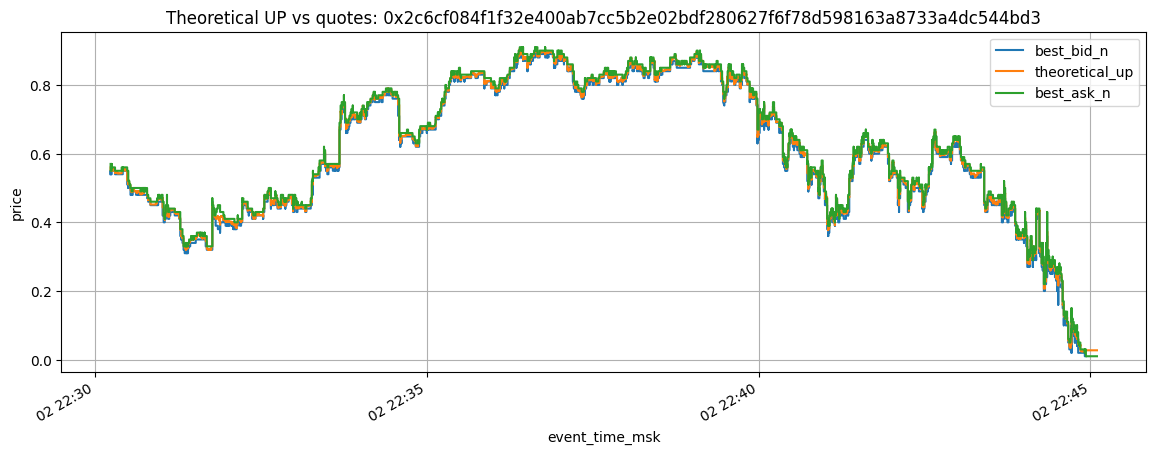

In [31]:
# список рынков, которые есть в данных
df_markets = ch_df(
    f"""
    SELECT
        market,
        min(event_time_msk) AS t_min,
        max(event_time_msk) AS t_max,
        count() AS rows
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    GROUP BY market
    ORDER BY t_min
    """
)
display(df_markets)

# если хочешь сравнить все найденные рынки:
markets = df_markets["market"].tolist()

# если хочешь только 2 конкретных подряд идущих рынка:
# markets = [
#     "market_id_1",
#     "market_id_2",
# ]

# рейтинг рынков по расхождению с theoretical_up
df_rank = rank_markets_by_theoretical_gap(
    markets=markets,
    min_total_size=50.0,   # глубина N
    ewm_span=50,           # сглаживание
)
display(df_rank)

# детальный график по рынку с максимальным расхождением
best_market = df_rank.iloc[0]["market"]

df_theory = build_theoretical_up_price_df(
    market=best_market,
    min_total_size=50.0,
    ewm_span=50,
)

display(df_theory.tail())

ax = df_theory.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Theoretical UP vs quotes: {best_market}",
)
ax.set_ylabel("price")

# где именно был максимальный edge
display(
    df_theory.sort_values("max_cross_side_edge_n", ascending=False).head(20)
)


In [1]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

# горизонт проверки: через сколько событий смотрим будущее
h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

# 1) sanity: как часто theoretical_up внутри текущего спреда
inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

# 2) основной прогнозный тест:
# baseline = текущий mid как прогноз будущего mid
baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()

# model = theoretical_up как прогноз будущего mid
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

# 3) directional accuracy
# если theoretical_up выше текущего mid -> сигнал "вверх"
valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

# 4) edge validation
# buy edge: theory выше ask
buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

# sell edge: bid выше theory
sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


NameError: name 'df_theory' is not defined

In [1]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

# горизонт проверки: через сколько событий смотрим будущее
h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

# 1) sanity: как часто theoretical_up внутри текущего спреда
inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

# 2) основной прогнозный тест:
# baseline = текущий mid как прогноз будущего mid
baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()

# model = theoretical_up как прогноз будущего mid
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

# 3) directional accuracy
# если theoretical_up выше текущего mid -> сигнал "вверх"
valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

# 4) edge validation
# buy edge: theory выше ask
buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

# sell edge: bid выше theory
sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


NameError: name 'df_theory' is not defined

In [2]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


In [3]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

# горизонт проверки: через сколько событий смотрим будущее
h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

# 1) sanity: как часто theoretical_up внутри текущего спреда
inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

# 2) основной прогнозный тест:
# baseline = текущий mid как прогноз будущего mid
baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()

# model = theoretical_up как прогноз будущего mid
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

# 3) directional accuracy
# если theoretical_up выше текущего mid -> сигнал "вверх"
valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

# 4) edge validation
# buy edge: theory выше ask
buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

# sell edge: bid выше theory
sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


NameError: name 'df_theory' is not defined

In [4]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

In [5]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

# горизонт проверки: через сколько событий смотрим будущее
h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

# 1) sanity: как часто theoretical_up внутри текущего спреда
inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

# 2) основной прогнозный тест:
# baseline = текущий mid как прогноз будущего mid
baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()

# model = theoretical_up как прогноз будущего mid
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

# 3) directional accuracy
# если theoretical_up выше текущего mid -> сигнал "вверх"
valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

# 4) edge validation
# buy edge: theory выше ask
buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

# sell edge: bid выше theory
sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


NameError: name 'df_theory' is not defined

In [6]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

df_theory = build_theoretical_up_price_df(
    market=market,
    min_total_size=50.0,
    ewm_span=50,
)

display(df_theory.tail())


NameError: name 'build_theoretical_up_price_df' is not defined

In [7]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _depth_price(level_sizes: dict, ordered_prices: list, min_total_size: float):
    total_size = 0.0
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size <= 0:
            continue
        total_size += size
        if total_size + 1e-12 >= float(min_total_size):
            return float(price), float(total_size)
    return float("nan"), float(total_size)


def build_depth_filtered_best_quotes_df(
    market: str,
    min_total_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return depth-filtered best bid/ask.

    The returned price is the marginal executable level where cumulative size first
    reaches `min_total_size`:
    - bid: start from best bid, then 0.001 lower, etc.
    - ask: start from best ask, then 0.001 higher, etc.

    If there are multiple snapshots for the same market, the latest one is used by
    default. Pass `snapshot_hash` to pin a specific snapshot segment.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
            best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "n": float(min_total_size),
                    "best_bid_n": best_bid_n,
                    "best_ask_n": best_ask_n,
                    "cum_bid_size_at_best_bid_n": cum_bid_size,
                    "cum_ask_size_at_best_ask_n": cum_ask_size,
                    "spread_n": best_ask_n - best_bid_n
                    if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


def build_theoretical_up_price_df(
    market: str,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
    asset_id: str = None,
    snapshot_hash: str = None,
) -> pd.DataFrame:
    """
    Build a practical theoretical-price proxy for the UP contract.

    The mechanism is:
    1) reconstruct depth-filtered bid/ask via cumulative depth `min_total_size`
    2) compute depth-filtered microprice
    3) smooth that microprice with an exponential moving average

    This is a microstructure-based fair value proxy, not a BTC spot/vol model.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")
    if int(ewm_span) <= 1:
        raise ValueError("ewm_span must be > 1")

    df = build_depth_filtered_best_quotes_df(
        market=market,
        min_total_size=min_total_size,
        asset_id=asset_id,
        snapshot_hash=snapshot_hash,
    ).copy()

    if df.empty:
        return df

    df = df.sort_values(["event_ts_ms", "event_time_msk"]).reset_index(drop=True)

    df["mid_n"] = (df["best_bid_n"] + df["best_ask_n"]) / 2.0

    denom = df["cum_bid_size_at_best_bid_n"] + df["cum_ask_size_at_best_ask_n"]
    df["microprice_n"] = df["mid_n"]
    good = denom > 0
    df.loc[good, "microprice_n"] = (
        df.loc[good, "best_ask_n"] * df.loc[good, "cum_bid_size_at_best_bid_n"]
        + df.loc[good, "best_bid_n"] * df.loc[good, "cum_ask_size_at_best_ask_n"]
    ) / denom.loc[good]

    df["theoretical_up_raw"] = df["microprice_n"]
    df["theoretical_up"] = (
        df["theoretical_up_raw"]
        .ewm(span=int(ewm_span), adjust=False, min_periods=1)
        .mean()
    )

    df["gap_to_bid_n"] = df["theoretical_up"] - df["best_bid_n"]
    df["gap_to_ask_n"] = df["best_ask_n"] - df["theoretical_up"]
    df["abs_gap_to_mid_n"] = (df["theoretical_up"] - df["mid_n"]).abs()

    # Positive value means the theoretical price is outside the current quote
    # and indicates a potential directional edge.
    df["buy_edge_vs_ask_n"] = df["theoretical_up"] - df["best_ask_n"]
    df["sell_edge_vs_bid_n"] = df["best_bid_n"] - df["theoretical_up"]
    df["max_cross_side_edge_n"] = df[["buy_edge_vs_ask_n", "sell_edge_vs_bid_n"]].max(axis=1)

    return df


def rank_markets_by_theoretical_gap(
    markets,
    min_total_size: float = 50.0,
    ewm_span: int = 50,
) -> pd.DataFrame:
    """
    Rank markets by how strongly their quoted prices diverge from the
    theoretical UP price proxy.

    Output metrics:
    - max_abs_gap_to_mid_n: largest |theoretical_up - mid_n|
    - p95_abs_gap_to_mid_n: 95th percentile of that gap
    - max_buy_edge_vs_ask_n: strongest positive buy edge vs ask
    - max_sell_edge_vs_bid_n: strongest positive sell edge vs bid
    - max_cross_side_edge_n: strongest quote dislocation on either side
    """
    rows = []

    for market in markets:
        try:
            df = build_theoretical_up_price_df(
                market=market,
                min_total_size=min_total_size,
                ewm_span=ewm_span,
            )

            if df.empty:
                rows.append(
                    {
                        "market": market,
                        "rows": 0,
                        "max_abs_gap_to_mid_n": float("nan"),
                        "p95_abs_gap_to_mid_n": float("nan"),
                        "max_buy_edge_vs_ask_n": float("nan"),
                        "max_sell_edge_vs_bid_n": float("nan"),
                        "max_cross_side_edge_n": float("nan"),
                        "last_theoretical_up": float("nan"),
                        "last_best_bid_n": float("nan"),
                        "last_best_ask_n": float("nan"),
                    }
                )
                continue

            last = df.iloc[-1]
            rows.append(
                {
                    "market": market,
                    "rows": int(len(df)),
                    "max_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].max()),
                    "p95_abs_gap_to_mid_n": float(df["abs_gap_to_mid_n"].quantile(0.95)),
                    "max_buy_edge_vs_ask_n": float(df["buy_edge_vs_ask_n"].max()),
                    "max_sell_edge_vs_bid_n": float(df["sell_edge_vs_bid_n"].max()),
                    "max_cross_side_edge_n": float(df["max_cross_side_edge_n"].max()),
                    "last_theoretical_up": float(last["theoretical_up"]),
                    "last_best_bid_n": float(last["best_bid_n"]),
                    "last_best_ask_n": float(last["best_ask_n"]),
                }
            )
        except Exception as e:
            rows.append(
                {
                    "market": market,
                    "rows": 0,
                    "max_abs_gap_to_mid_n": float("nan"),
                    "p95_abs_gap_to_mid_n": float("nan"),
                    "max_buy_edge_vs_ask_n": float("nan"),
                    "max_sell_edge_vs_bid_n": float("nan"),
                    "max_cross_side_edge_n": float("nan"),
                    "last_theoretical_up": float("nan"),
                    "last_best_bid_n": float("nan"),
                    "last_best_ask_n": float("nan"),
                    "error": repr(e),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    return out.sort_values(
        ["max_cross_side_edge_n", "p95_abs_gap_to_mid_n"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

In [8]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

df_theory = build_theoretical_up_price_df(
    market=market,
    min_total_size=50.0,
    ewm_span=50,
)

display(df_theory.tail())


,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,n,best_bid_n,best_ask_n,cum_bid_size_at_best_bid_n,cum_ask_size_at_best_ask_n,spread_n,mid_n,microprice_n,theoretical_up_raw,theoretical_up,gap_to_bid_n,gap_to_ask_n,abs_gap_to_mid_n,buy_edge_vs_ask_n,sell_edge_vs_bid_n,max_cross_side_edge_n
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728511.82,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,50.0,NaN,0.01,11.0,728517.89,NaN,NaN,NaN,NaN,0.02734,NaN,-0.01734,NaN,0.01734,NaN,0.01734


In [9]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


,rows_checked,inside_spread_rate,baseline_mae_mid_to_future_mid,model_mae_theory_to_future_mid,baseline_rmse,model_rmse,directional_accuracy,buy_cases,buy_success_rate,sell_cases,sell_success_rate
0,163900,0.9495,0.001718,0.004039,0.003988,0.005741,0.547724,4566,0.035699,3711,0.0609


In [10]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 20.0  # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")

NameError: name 'build_best_quotes_min_level_df' is not defined

In [11]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


def _sql_quote(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def _depth_price(level_sizes: dict, ordered_prices: list, min_total_size: float):
    total_size = 0.0
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size <= 0:
            continue
        total_size += size
        if total_size + 1e-12 >= float(min_total_size):
            return float(price), float(total_size)
    return float("nan"), float(total_size)


def _best_price_with_min_level(level_sizes: dict, ordered_prices: list, min_level_size: float):
    for price in ordered_prices:
        size = float(level_sizes.get(price, 0.0) or 0.0)
        if size + 1e-12 >= float(min_level_size):
            return float(price), float(size)
    return float("nan"), 0.0


def build_best_quotes_min_level_df(
    market: str,
    min_level_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return best bid/ask with
    a per-level size floor.

    - best_bid: highest bid price with size >= min_level_size
    - best_ask: lowest ask price with size >= min_level_size

    This is a cleaner alternative to raw top-of-book when tiny residual sizes
    create noisy or crossed quotes.
    """
    if float(min_level_size) <= 0:
        raise ValueError("min_level_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid, best_bid_size = _best_price_with_min_level(bid_sizes, bid_prices_desc, min_level_size)
        best_ask, best_ask_size = _best_price_with_min_level(ask_sizes, ask_prices_asc, min_level_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "min_level_size": float(min_level_size),
                "best_bid_filtered": best_bid,
                "best_ask_filtered": best_ask,
                "best_bid_level_size": best_bid_size,
                "best_ask_level_size": best_ask_size,
                "spread_filtered": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid, best_bid_size = _best_price_with_min_level(
                bid_sizes, bid_prices_desc, min_level_size
            )
            best_ask, best_ask_size = _best_price_with_min_level(
                ask_sizes, ask_prices_asc, min_level_size
            )
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "min_level_size": float(min_level_size),
                    "best_bid_filtered": best_bid,
                    "best_ask_filtered": best_ask,
                    "best_bid_level_size": best_bid_size,
                    "best_ask_level_size": best_ask_size,
                    "spread_filtered": best_ask - best_bid
                    if pd.notna(best_bid) and pd.notna(best_ask)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid, best_bid_size = _best_price_with_min_level(bid_sizes, bid_prices_desc, min_level_size)
        best_ask, best_ask_size = _best_price_with_min_level(ask_sizes, ask_prices_asc, min_level_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "min_level_size": float(min_level_size),
                "best_bid_filtered": best_bid,
                "best_ask_filtered": best_ask,
                "best_bid_level_size": best_bid_size,
                "best_ask_level_size": best_ask_size,
                "spread_filtered": best_ask - best_bid
                if pd.notna(best_bid) and pd.notna(best_ask)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


def build_depth_filtered_best_quotes_df(
    market: str,
    min_total_size: float,
    asset_id: str = None,
    snapshot_hash: str = None,
    include_snapshot_point: bool = True,
) -> pd.DataFrame:
    """
    Reconstruct the UP-side book for a market and return depth-filtered best bid/ask.

    The returned price is the marginal executable level where cumulative size first
    reaches `min_total_size`:
    - bid: start from best bid, then 0.001 lower, etc.
    - ask: start from best ask, then 0.001 higher, etc.

    If there are multiple snapshots for the same market, the latest one is used by
    default. Pass `snapshot_hash` to pin a specific snapshot segment.
    """
    if float(min_total_size) <= 0:
        raise ValueError("min_total_size must be > 0")

    where_parts = [f"market = {_sql_quote(market)}"]
    if asset_id:
        where_parts.append(f"asset_id = {_sql_quote(asset_id)}")
    if snapshot_hash:
        where_parts.append(f"hash = {_sql_quote(snapshot_hash)}")
    snapshot_where = " AND ".join(where_parts)

    df_snapshot_meta = ch_df(
        f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE {snapshot_where}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
    )
    if df_snapshot_meta.empty:
        raise ValueError("No matching snapshot found in orderbook")

    snapshot_row = df_snapshot_meta.iloc[0]
    selected_market = str(snapshot_row["market"])
    selected_asset_id = str(snapshot_row["asset_id"])
    selected_hash = str(snapshot_row["hash"])
    snapshot_ts_ms = int(snapshot_row["snapshot_ts_ms"])
    snapshot_time_msk = snapshot_row["snapshot_time_msk"]

    df_snapshot = ch_df(
        f"""
SELECT
    side,
    price,
    size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND hash = {_sql_quote(selected_hash)}
ORDER BY price ASC
"""
    )
    if df_snapshot.empty:
        raise ValueError("Snapshot rows not found")

    price_grid = sorted(float(x) for x in df_snapshot["price"].tolist())
    bid_prices_desc = list(reversed(price_grid))
    ask_prices_asc = price_grid[:]

    bid_sizes = {price: 0.0 for price in price_grid}
    ask_sizes = {price: 0.0 for price in price_grid}

    for row in df_snapshot.itertuples(index=False):
        price = float(row.price)
        size = float(row.size)
        side = str(row.side)
        if side == "bid":
            bid_sizes[price] = size
        elif side == "ask":
            ask_sizes[price] = size

    records = []

    if include_snapshot_point:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": snapshot_time_msk,
                "event_ts_ms": snapshot_ts_ms,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    df_pc = ch_df(
        f"""
SELECT
    event_time_msk,
    event_ts_ms,
    side,
    price,
    size
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = {_sql_quote(selected_market)}
  AND asset_id = {_sql_quote(selected_asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
    )

    if df_pc.empty:
        return pd.DataFrame(records)

    current_ts = None
    current_time_msk = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time_msk = row.event_time_msk
        elif row_ts != current_ts:
            best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
            best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append(
                {
                    "event_time_msk": current_time_msk,
                    "event_ts_ms": current_ts,
                    "market": selected_market,
                    "asset_id": selected_asset_id,
                    "snapshot_hash": selected_hash,
                    "n": float(min_total_size),
                    "best_bid_n": best_bid_n,
                    "best_ask_n": best_ask_n,
                    "cum_bid_size_at_best_bid_n": cum_bid_size,
                    "cum_ask_size_at_best_ask_n": cum_ask_size,
                    "spread_n": best_ask_n - best_bid_n
                    if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                    else float("nan"),
                }
            )
            current_ts = row_ts
            current_time_msk = row.event_time_msk

        price = float(row.price)
        delta_size = float(row.size)
        side = str(row.side)

        if side == "bid":
            new_size = bid_sizes.get(price, 0.0) + delta_size
            bid_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size
        elif side == "ask":
            new_size = ask_sizes.get(price, 0.0) + delta_size
            ask_sizes[price] = 0.0 if abs(new_size) <= 1e-12 else new_size

    if current_ts is not None:
        best_bid_n, cum_bid_size = _depth_price(bid_sizes, bid_prices_desc, min_total_size)
        best_ask_n, cum_ask_size = _depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append(
            {
                "event_time_msk": current_time_msk,
                "event_ts_ms": current_ts,
                "market": selected_market,
                "asset_id": selected_asset_id,
                "snapshot_hash": selected_hash,
                "n": float(min_total_size),
                "best_bid_n": best_bid_n,
                "best_ask_n": best_ask_n,
                "cum_bid_size_at_best_bid_n": cum_bid_size,
                "cum_ask_size_at_best_ask_n": cum_ask_size,
                "spread_n": best_ask_n - best_bid_n
                if pd.notna(best_bid_n) and pd.notna(best_ask_n)
                else float("nan"),
            }
        )

    return pd.DataFrame(records)


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

,event_time_msk,event_ts_ms,market,asset_id,snapshot_hash,min_level_size,best_bid_filtered,best_ask_filtered,best_bid_level_size,best_ask_level_size,spread_filtered
164435,2026-03-02 22:45:06,1772480706130,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728511.82,NaN
164436,2026-03-02 22:45:06,1772480706138,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728511.82,NaN
164437,2026-03-02 22:45:06,1772480706291,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN
164438,2026-03-02 22:45:06,1772480706427,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN
164439,2026-03-02 22:45:06,1772480706454,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3,29891709321733542309251713964207212086391082054561156726047402815033078161433,706f03b7fd28f96e2bfa6ef6bf09ef41524df211,20.0,NaN,0.01,0.0,728517.89,NaN


Text(0, 0.5, 'price')

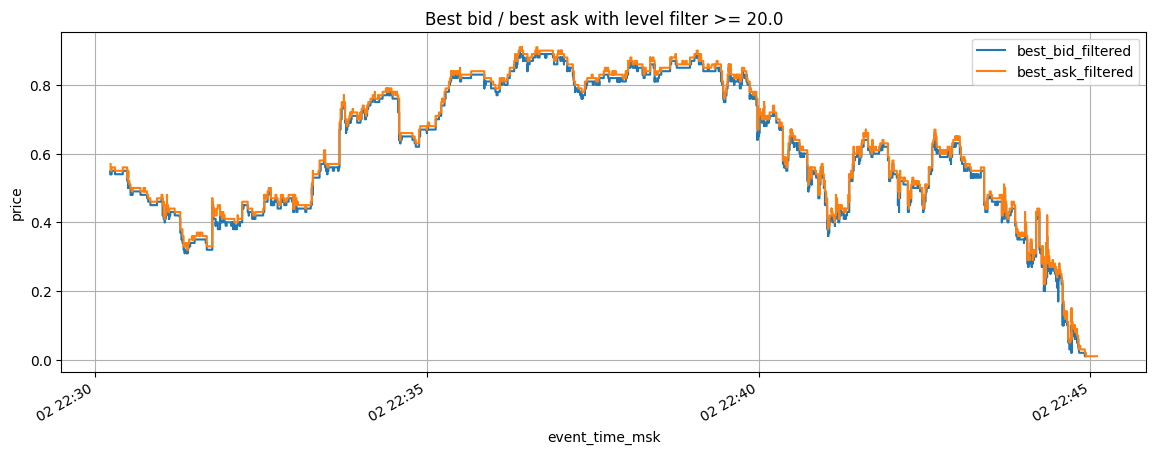

In [12]:
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
min_level_size = 20.0  # попробуй 5, 10, 20

df_quotes = build_best_quotes_min_level_df(
    market=market,
    min_level_size=min_level_size,
)

display(df_quotes.tail())

ax = df_quotes.plot(
    x="event_time_msk",
    y=["best_bid_filtered", "best_ask_filtered"],
    figsize=(14, 5),
    grid=True,
    title=f"Best bid / best ask with level filter >= {min_level_size}",
)
ax.set_ylabel("price")

In [13]:
import pandas as pd

df_test = df_theory.copy().sort_values("event_ts_ms").reset_index(drop=True)

h = 20

df_test["future_mid_n"] = df_test["mid_n"].shift(-h)
df_test["future_bid_n"] = df_test["best_bid_n"].shift(-h)
df_test["future_ask_n"] = df_test["best_ask_n"].shift(-h)

valid = df_test.dropna(subset=["future_mid_n"]).copy()

inside_spread_rate = (
    (
        (valid["theoretical_up"] >= valid["best_bid_n"]) &
        (valid["theoretical_up"] <= valid["best_ask_n"])
    ).mean()
)

baseline_mae = (valid["mid_n"] - valid["future_mid_n"]).abs().mean()
model_mae = (valid["theoretical_up"] - valid["future_mid_n"]).abs().mean()

baseline_rmse = (((valid["mid_n"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5
model_rmse = (((valid["theoretical_up"] - valid["future_mid_n"]) ** 2).mean()) ** 0.5

valid["signal_up"] = valid["theoretical_up"] > valid["mid_n"]
valid["future_up"] = valid["future_mid_n"] > valid["mid_n"]
directional_accuracy = (valid["signal_up"] == valid["future_up"]).mean()

buy_cases = valid[valid["buy_edge_vs_ask_n"] > 0].copy()
buy_success_rate = (
    (buy_cases["future_mid_n"] > buy_cases["best_ask_n"]).mean()
    if len(buy_cases) else float("nan")
)

sell_cases = valid[valid["sell_edge_vs_bid_n"] > 0].copy()
sell_success_rate = (
    (sell_cases["future_mid_n"] < sell_cases["best_bid_n"]).mean()
    if len(sell_cases) else float("nan")
)

summary = pd.DataFrame(
    [{
        "rows_checked": len(valid),
        "inside_spread_rate": inside_spread_rate,
        "baseline_mae_mid_to_future_mid": baseline_mae,
        "model_mae_theory_to_future_mid": model_mae,
        "baseline_rmse": baseline_rmse,
        "model_rmse": model_rmse,
        "directional_accuracy": directional_accuracy,
        "buy_cases": len(buy_cases),
        "buy_success_rate": buy_success_rate,
        "sell_cases": len(sell_cases),
        "sell_success_rate": sell_success_rate,
    }]
)

display(summary)


,rows_checked,inside_spread_rate,baseline_mae_mid_to_future_mid,model_mae_theory_to_future_mid,baseline_rmse,model_rmse,directional_accuracy,buy_cases,buy_success_rate,sell_cases,sell_success_rate
0,163900,0.9495,0.001718,0.004039,0.003988,0.005741,0.547724,4566,0.035699,3711,0.0609


In [14]:
import requests
import pandas as pd

market_id = "твой_market_id"
url = f"https://gamma-api.polymarket.com/markets/{market_id}"
meta = requests.get(url, timeout=30).json()

fields = {
    "lowerBound": meta.get("lowerBound"),
    "upperBound": meta.get("upperBound"),
    "groupItemThreshold": meta.get("groupItemThreshold"),
    "question": meta.get("question"),
    "groupItemTitle": meta.get("groupItemTitle"),
}

pd.DataFrame([fields]).T


,0
lowerBound,None
upperBound,None
groupItemThreshold,None
question,None
groupItemTitle,None


In [15]:
market_id = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

df_meta = ch_df(f"""
SELECT 1
""")


In [16]:
import requests
import pandas as pd

market_id = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"
url = f"https://gamma-api.polymarket.com/markets/{market_id}"
meta = requests.get(url, timeout=30).json()

fields = {
    "lowerBound": meta.get("lowerBound"),
    "upperBound": meta.get("upperBound"),
    "groupItemThreshold": meta.get("groupItemThreshold"),
    "question": meta.get("question"),
    "groupItemTitle": meta.get("groupItemTitle"),
}

pd.DataFrame([fields]).T

,0
lowerBound,None
upperBound,None
groupItemThreshold,None
question,None
groupItemTitle,None


In [17]:
import requests
import pandas as pd

condition_id = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

url = "https://gamma-api.polymarket.com/markets"
params = {
    "limit": 1000,
    "active": "true",
    "closed": "false",
}

markets = requests.get(url, params=params, timeout=30).json()

row = next(
    (m for m in markets if str(m.get("conditionId", "")).lower() == condition_id.lower()),
    None
)

if row is None:
    raise ValueError("Market with this conditionId not found")

fields = {
    "gamma_market_id": row.get("id"),
    "conditionId": row.get("conditionId"),
    "question": row.get("question"),
    "groupItemTitle": row.get("groupItemTitle"),
    "groupItemThreshold": row.get("groupItemThreshold"),
    "lowerBound": row.get("lowerBound"),
    "upperBound": row.get("upperBound"),
    "endDate": row.get("endDate"),
    "secondsDelay": row.get("secondsDelay"),
}

pd.DataFrame([fields]).T


ValueError: Market with this conditionId not found

In [18]:
import requests
import pandas as pd

condition_id = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"

url = "https://gamma-api.polymarket.com/markets"
params = {
    "condition_ids": [condition_id],
}

markets = requests.get(url, params=params, timeout=30).json()

if not markets:
    raise ValueError("Market not found by condition_id")

row = markets[0]

fields = {
    "gamma_market_id": row.get("id"),
    "conditionId": row.get("conditionId"),
    "groupItemThreshold": row.get("groupItemThreshold"),
    "lowerBound": row.get("lowerBound"),
    "upperBound": row.get("upperBound"),
    "question": row.get("question"),
    "groupItemTitle": row.get("groupItemTitle"),
    "endDate": row.get("endDate"),
    "secondsDelay": row.get("secondsDelay"),
}

pd.DataFrame([fields]).T


,0
gamma_market_id,1478027
conditionId,0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3
groupItemThreshold,0
lowerBound,None
upperBound,None
question,"Bitcoin Up or Down - March 2, 2:30PM-2:45PM ET"
groupItemTitle,None
endDate,2026-03-02T19:45:00Z
secondsDelay,None


In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [2]:
from IPython.display import display
from jupyter_clickhouse_workflow import ch_df, DB_NAME, SPOT_TABLE

# Проверить, что таблица есть
display(ch_df(f"SHOW TABLES FROM {DB_NAME}"))

# Вывести последние строки из btc_spot
df_spot = ch_df(f"""
SELECT
    event_time_msk,
    event_ts_ms,
    symbol,
    value,
    source_topic
FROM {DB_NAME}.{SPOT_TABLE}
ORDER BY event_ts_ms DESC
LIMIT 200
""")

display(df_spot)


TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done
                            check_name  value_num                     details
                     bad_snapshots_cnt        0.0                   must be 0
               orderbook_bad_grid_rows        0.0                   must be 0
        orderbook_bad_price_range_rows        0.0                   must be 0
        orderbook_duplicate_level_rows        0.0                   must be 0
orderbook_expected_rows_from_snapshots        0.0 should equal orderbook_rows
          orderbook_negative_size_rows        0.0                   must be 0
                        orderbook_rows        0.0                            
                pricechange_avg_lag_ms        NaN               informational
             pricechange_bad_grid_rows        0.0                   must be 0
      pricechange_bad_price_range_rows        0.0                   must be 0
             pricec

""


IndexError: single positional indexer is out-of-bounds

In [2]:
from IPython.display import display
from jupyter_clickhouse_workflow import ch_df, DB_NAME, SPOT_TABLE

# Проверить, что таблица есть
display(ch_df(f"SHOW TABLES FROM {DB_NAME}"))

# Вывести последние строки из btc_spot
df_spot = ch_df(f"""
SELECT
    event_time_msk,
    event_ts_ms,
    symbol,
    value,
    source_topic
FROM {DB_NAME}.{SPOT_TABLE}
ORDER BY event_ts_ms DESC
LIMIT 200
""")

display(df_spot)


TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done
                            check_name  value_num                     details
                     bad_snapshots_cnt        0.0                   must be 0
               orderbook_bad_grid_rows        0.0                   must be 0
        orderbook_bad_price_range_rows        0.0                   must be 0
        orderbook_duplicate_level_rows        0.0                   must be 0
orderbook_expected_rows_from_snapshots        0.0 should equal orderbook_rows
          orderbook_negative_size_rows        0.0                   must be 0
                        orderbook_rows        0.0                            
                pricechange_avg_lag_ms        NaN               informational
             pricechange_bad_grid_rows        0.0                   must be 0
      pricechange_bad_price_range_rows        0.0                   must be 0
             pricec

""


IndexError: single positional indexer is out-of-bounds

In [3]:
from IPython.display import display
from jupyter_clickhouse_workflow import ch_df, DB_NAME, SPOT_TABLE

# Проверить, что таблица есть
display(ch_df(f"SHOW TABLES FROM {DB_NAME}"))

# Вывести последние строки из btc_spot
df_spot = ch_df(f"""
SELECT
    event_time_msk,
    event_ts_ms,
    symbol,
    value,
    source_topic
FROM {DB_NAME}.{SPOT_TABLE}
ORDER BY event_ts_ms DESC
LIMIT 200
""")

display(df_spot)

TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done
                            check_name  value_num                     details
                     bad_snapshots_cnt        0.0                   must be 0
               orderbook_bad_grid_rows        0.0                   must be 0
        orderbook_bad_price_range_rows        0.0                   must be 0
        orderbook_duplicate_level_rows        0.0                   must be 0
orderbook_expected_rows_from_snapshots        0.0 should equal orderbook_rows
          orderbook_negative_size_rows        0.0                   must be 0
                        orderbook_rows        0.0                            
                pricechange_avg_lag_ms        NaN               informational
             pricechange_bad_grid_rows        0.0                   must be 0
      pricechange_bad_price_range_rows        0.0                   must be 0
             pricec

""


IndexError: single positional indexer is out-of-bounds

In [4]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

res = c.query(f"""
SELECT event_time_msk, event_ts_ms, symbol, value, source_topic
FROM {db}.{spot_table}
ORDER BY event_ts_ms DESC
LIMIT 200
""")

df_btc = pd.DataFrame(res.result_rows, columns=res.column_names)
display(df_btc)


,event_time_msk,event_ts_ms,symbol,value,source_topic
0,2026-03-06 13:57:22,1772794642000,btc/usd,70588.409745,crypto_prices_chainlink
1,2026-03-06 13:57:21,1772794641000,btc/usd,70590.889608,crypto_prices_chainlink
2,2026-03-06 13:57:20,1772794640000,btc/usd,70590.553030,crypto_prices_chainlink
3,2026-03-06 13:57:19,1772794639000,btc/usd,70580.644159,crypto_prices_chainlink
4,2026-03-06 13:57:18,1772794638000,btc/usd,70568.647226,crypto_prices_chainlink
...,...,...,...,...,...
110,2026-03-06 13:55:32,1772794532000,btc/usd,70515.805956,crypto_prices_chainlink
111,2026-03-06 13:55:31,1772794531000,btc/usd,70515.198750,crypto_prices_chainlink
112,2026-03-06 13:55:30,1772794530000,btc/usd,70516.079737,crypto_prices_chainlink
113,2026-03-06 13:55:29,1772794529000,btc/usd,70515.428161,crypto_prices_chainlink


In [5]:
TRUNCATE TABLE polyk.btc_spot;


SyntaxError: invalid syntax (2567933628.py, line 1)

In [6]:
c.query(f"""
TRUNCATE TABLE polyk.btc_spot;
""")

In [7]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.{polyk.btc_spot}",
]

for t in tables_to_truncate:
    print("ОЧИСТКА", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Готово")

NameError: name 'polyk' is not defined

In [8]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.polyk.btc_spot",
]

for t in tables_to_truncate:
    print("ОЧИСТКА", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Готово")

ОЧИСТКА polyk.polyk.btc_spot


DatabaseError: HTTP driver received HTTP status 400, server response: Code: 62, e.displayText() = DB::Exception: Syntax error: failed at position 27: .btc_spot. Expected one of: ON, INTO OUTFILE, FORMAT, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [9]:
from jupyter_clickhouse_workflow import ch_cmd

ch_cmd("TRUNCATE TABLE polyk.btc_spot")
print("Готово")


ОЧИСТКА polyk.orderbook
ОЧИСТКА polyk.pricechange
ОЧИСТКА polyk.ingest_heartbeat
ОЧИСТКА polyk.ingest_service_log
Готово


DatabaseError: HTTP driver received HTTP status 400, server response: Code: 62, e.displayText() = DB::Exception: Syntax error: failed at position 59 (line 3, col 51): количество_snapshot,
  count() AS всего_строк_orderbook,
  count() / 999 AS строк_на_snapshot_деление_на_999
FROM polyk.orde. Unrecognized token, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [10]:
import os
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
)

c.command("TRUNCATE TABLE polyk.btc_spot")
print("Готово")


Готово


In [11]:
from jupyter_clickhouse_workflow import ch_cmd

ch_cmd("TRUNCATE TABLE polyk.btc_spot")
print("Готово")

ОЧИСТКА polyk.orderbook
ОЧИСТКА polyk.pricechange
ОЧИСТКА polyk.ingest_heartbeat
ОЧИСТКА polyk.ingest_service_log
Готово


DatabaseError: HTTP driver received HTTP status 400, server response: Code: 62, e.displayText() = DB::Exception: Syntax error: failed at position 59 (line 3, col 51): количество_snapshot,
  count() AS всего_строк_orderbook,
  count() / 999 AS строк_на_snapshot_деление_на_999
FROM polyk.orde. Unrecognized token, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [12]:
c.query("SELECT count() FROM polyk.btc_spot").result_rows


[(0,)]

In [13]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    event_time_msk,
    event_ts_ms,
    value AS btc_price
FROM {db}.{spot_table}
WHERE symbol = 'btc/usd'
ORDER BY event_ts_ms
"""

res = c.query(sql)
df = pd.DataFrame(res.result_rows, columns=res.column_names)

df["delta_abs"] = df["btc_price"].diff()          # абсолютное изменение
df["delta_pct"] = df["btc_price"].pct_change()    # относительное изменение
df = df.dropna().reset_index(drop=True)

out_file = "btc_price_changes.csv"
df.to_csv(out_file, index=False)

print(f"Сохранено: {out_file}, строк: {len(df)}")


Сохранено: btc_price_changes.csv, строк: 2208


In [14]:
import os
import re
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

# ===== ПАРАМЕТРЫ =====
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"  # conditionId
sigma = 0.8197
r = 0.0
duration_min = 15
symbol = "btc/usd"
db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

# df_quotes должен уже быть в ноутбуке и содержать:
# event_ts_ms, best_bid_n, best_ask_n
# пример:
# df_quotes = build_depth_filtered_best_quotes_df(market=market, min_total_size=50.0)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

# 1) мета рынка (endDate)
meta = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
).json()

row = meta[0] if isinstance(meta, list) and len(meta) else meta.get("data", [None])[0]
end_raw = row.get("endDate") or row.get("end_date") or row.get("endTime") or row.get("end_time")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

# 2) price_to_beat = первый тик нового рынка
p2b_q = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
""").result_rows

if not p2b_q:
    raise ValueError("Не найден первый spot value нового рынка")
K = float(p2b_q[0][1])

# 3) spot-ряд для merge_asof
spot_rows = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms - 60_000}
  AND event_ts_ms <= {end_ts_ms}
ORDER BY event_ts_ms ASC
""")
df_spot = pd.DataFrame(spot_rows.result_rows, columns=spot_rows.column_names)

# 4) BS для бинарного UP: P(UP)=N(d2)
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(df_q, df_s, on="event_ts_ms", direction="backward")
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = K
df_bs["time_to_expiry_sec"] = ((end_ts_ms - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau"] = df_bs["time_to_expiry_sec"] / (365 * 24 * 60 * 60)

mask = df_bs["tau"] > 0
df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= K, 1.0, 0.0)

d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / K) +
    (r - 0.5 * sigma**2) * df_bs.loc[mask, "tau"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0))))
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

# 5) edge
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)

display(df_bs[[
    "event_time_msk", "event_ts_ms",
    "best_bid_n", "best_ask_n",
    "spot_value", "price_to_beat",
    "theoretical_up_bs",
    "buy_edge_bs", "sell_edge_bs", "max_cross_side_edge_bs"
]].tail(30))


NameError: name 'df_quotes' is not defined

In [15]:
# если функция уже загружена в ноутбуке:
df_quotes = build_depth_filtered_best_quotes_df(
    market=market,
    min_total_size=50.0
)

display(df_quotes.tail())


NameError: name 'build_depth_filtered_best_quotes_df' is not defined

In [16]:
q = f"""
SELECT
    event_time_msk,
    event_ts_ms,
    maxIf(price, side='bid') AS best_bid_n,
    minIf(price, side='ask') AS best_ask_n
FROM polyk.orderbook
WHERE market = '{market}'
GROUP BY event_time_msk, event_ts_ms
ORDER BY event_ts_ms
"""
res = c.query(q)
df_quotes = pd.DataFrame(res.result_rows, columns=res.column_names)
display(df_quotes.tail())


""


In [17]:
import os
import re
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

# ===== ПАРАМЕТРЫ =====
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"  # conditionId
sigma = 0.8197
r = 0.0
duration_min = 15
symbol = "btc/usd"
db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

# df_quotes должен уже быть в ноутбуке и содержать:
# event_ts_ms, best_bid_n, best_ask_n
# пример:
# df_quotes = build_depth_filtered_best_quotes_df(market=market, min_total_size=50.0)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

# 1) мета рынка (endDate)
meta = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
).json()

row = meta[0] if isinstance(meta, list) and len(meta) else meta.get("data", [None])[0]
end_raw = row.get("endDate") or row.get("end_date") or row.get("endTime") or row.get("end_time")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

# 2) price_to_beat = первый тик нового рынка
p2b_q = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
""").result_rows

if not p2b_q:
    raise ValueError("Не найден первый spot value нового рынка")
K = float(p2b_q[0][1])

# 3) spot-ряд для merge_asof
spot_rows = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms - 60_000}
  AND event_ts_ms <= {end_ts_ms}
ORDER BY event_ts_ms ASC
""")
df_spot = pd.DataFrame(spot_rows.result_rows, columns=spot_rows.column_names)

# 4) BS для бинарного UP: P(UP)=N(d2)
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(df_q, df_s, on="event_ts_ms", direction="backward")
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = K
df_bs["time_to_expiry_sec"] = ((end_ts_ms - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau"] = df_bs["time_to_expiry_sec"] / (365 * 24 * 60 * 60)

mask = df_bs["tau"] > 0
df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= K, 1.0, 0.0)

d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / K) +
    (r - 0.5 * sigma**2) * df_bs.loc[mask, "tau"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0))))
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

# 5) edge
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)

display(df_bs[[
    "event_time_msk", "event_ts_ms",
    "best_bid_n", "best_ask_n",
    "spot_value", "price_to_beat",
    "theoretical_up_bs",
    "buy_edge_bs", "sell_edge_bs", "max_cross_side_edge_bs"
]].tail(30))



KeyError: 'event_ts_ms'

In [18]:
q = f"""
SELECT
    toUnixTimestamp(event_time_msk) * 1000 AS event_ts_ms,
    event_time_msk,
    maxIf(price, side='bid') AS best_bid_n,
    minIf(price, side='ask') AS best_ask_n
FROM polyk.orderbook
WHERE market = '{market}'
GROUP BY event_time_msk
ORDER BY event_ts_ms
"""
res = c.query(q)
df_quotes = pd.DataFrame(res.result_rows, columns=res.column_names)

display(df_quotes.head())
display(df_quotes.tail())
print(df_quotes.columns.tolist())


""


""


[]


In [19]:
import os
import re
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

# ===== ПАРАМЕТРЫ =====
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"  # conditionId
sigma = 0.8197
r = 0.0
duration_min = 15
symbol = "btc/usd"
db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

# df_quotes должен уже быть в ноутбуке и содержать:
# event_ts_ms, best_bid_n, best_ask_n
# пример:
# df_quotes = build_depth_filtered_best_quotes_df(market=market, min_total_size=50.0)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

# 1) мета рынка (endDate)
meta = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
).json()

row = meta[0] if isinstance(meta, list) and len(meta) else meta.get("data", [None])[0]
end_raw = row.get("endDate") or row.get("end_date") or row.get("endTime") or row.get("end_time")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

# 2) price_to_beat = первый тик нового рынка
p2b_q = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
""").result_rows

if not p2b_q:
    raise ValueError("Не найден первый spot value нового рынка")
K = float(p2b_q[0][1])

# 3) spot-ряд для merge_asof
spot_rows = c.query(f"""
SELECT event_ts_ms, value
FROM {db}.{spot_table}
WHERE symbol = '{symbol}'
  AND event_ts_ms >= {start_ts_ms - 60_000}
  AND event_ts_ms <= {end_ts_ms}
ORDER BY event_ts_ms ASC
""")
df_spot = pd.DataFrame(spot_rows.result_rows, columns=spot_rows.column_names)

# 4) BS для бинарного UP: P(UP)=N(d2)
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(df_q, df_s, on="event_ts_ms", direction="backward")
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = K
df_bs["time_to_expiry_sec"] = ((end_ts_ms - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau"] = df_bs["time_to_expiry_sec"] / (365 * 24 * 60 * 60)

mask = df_bs["tau"] > 0
df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= K, 1.0, 0.0)

d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / K) +
    (r - 0.5 * sigma**2) * df_bs.loc[mask, "tau"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0))))
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

# 5) edge
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)

display(df_bs[[
    "event_time_msk", "event_ts_ms",
    "best_bid_n", "best_ask_n",
    "spot_value", "price_to_beat",
    "theoretical_up_bs",
    "buy_edge_bs", "sell_edge_bs", "max_cross_side_edge_bs"
]].tail(30))

KeyError: 'event_ts_ms'

In [20]:
import os
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

# ===== ПАРАМЕТРЫ =====
market = "0x2c6cf084f1f32e400ab7cc5b2e02bdf280627f6f78d598163a8733a4dc544bd3"  # conditionId
min_total_size = 50.0
sigma = 0.8197
r = 0.0
duration_min = 15
symbol = "btc/usd"

# ===== КОНФИГ =====
load_dotenv(".env", override=True)
DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")
GAMMA_API = "https://gamma-api.polymarket.com"

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v):
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes, ordered_prices, n):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

# ===== 1) Восстановление depth-filtered котировок =====
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
m = c.query(meta_sql)
if not m.result_rows:
    raise ValueError("Для market не найден snapshot в orderbook")

mrow = dict(zip(m.column_names, m.result_rows[0]))
asset_id = str(mrow["asset_id"])
ob_hash = str(mrow["hash"])
snapshot_ts_ms = int(mrow["snapshot_ts_ms"])
snapshot_time_msk = mrow["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap = c.query(snap_sql)
df_snap = pd.DataFrame(snap.result_rows, columns=snap.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}
for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []
bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
    "cum_bid_size_at_best_bid_n": cb,
    "cum_ask_size_at_best_ask_n": ca,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc = c.query(pc_sql)
df_pc = pd.DataFrame(pc.result_rows, columns=pc.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None
    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)
        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
                "cum_bid_size_at_best_bid_n": cb,
                "cum_ask_size_at_best_ask_n": ca,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)
        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
            "cum_bid_size_at_best_bid_n": cb,
            "cum_ask_size_at_best_ask_n": ca,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("Не удалось собрать df_quotes")

# ===== 2) endDate + price_to_beat =====
resp = requests.get(
    f"{GAMMA_API}/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
)
resp.raise_for_status()
payload = resp.json()

markets = payload if isinstance(payload, list) else payload.get("data", [])
if not markets:
    raise ValueError("Gamma не вернул market по condition_id")

g = markets[0]
end_raw = g.get("endDate") or g.get("end_date") or g.get("endTime") or g.get("end_time")
if not end_raw:
    raise ValueError("В Gamma нет endDate/endTime")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - int(duration_min) * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows

mode = "first_at_or_after_start"
if not p2b:
    p2b_sql_fb = f"""
    SELECT event_ts_ms, value
    FROM {DB}.{SPOT_TABLE}
    WHERE symbol = {q(symbol.lower())}
      AND event_ts_ms < {start_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """
    p2b = c.query(p2b_sql_fb).result_rows
    mode = "last_before_start_fallback"

if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")
price_to_beat = float(p2b[0][1])

# ===== 3) Spot ряд для merge_asof =====
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {max(0, int(df_quotes['event_ts_ms'].min()) - 120000)}
  AND event_ts_ms <= {max(end_ts_ms, int(df_quotes['event_ts_ms'].max()))}
ORDER BY event_ts_ms ASC
"""
spot_rows = c.query(spot_sql)
df_spot = pd.DataFrame(spot_rows.result_rows, columns=spot_rows.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot в окне рынка")

# ===== 4) Black-Scholes (digital call): P(UP)=N(d2) =====
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(df_q, df_s[["event_ts_ms", "value"]], on="event_ts_ms", direction="backward")
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = price_to_beat
df_bs["sigma"] = float(sigma)
df_bs["r"] = float(r)
df_bs["market_end_ts_ms"] = int(end_ts_ms)
df_bs["time_to_expiry_sec"] = ((df_bs["market_end_ts_ms"] - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau_years"] = df_bs["time_to_expiry_sec"] / (365.0 * 24.0 * 60.0 * 60.0)

def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

vals = []
for s, tau in zip(df_bs["spot_value"].astype(float), df_bs["tau_years"].astype(float)):
    if tau <= 0:
        vals.append(1.0 if s >= price_to_beat else 0.0)
        continue
    d2 = (math.log(s / price_to_beat) + (r - 0.5 * sigma * sigma) * tau) / (sigma * math.sqrt(tau))
    vals.append(float(min(1.0, max(0.0, norm_cdf(d2)))))

df_bs["theoretical_up_bs"] = vals
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)

print("mode price_to_beat:", mode)
print("price_to_beat:", price_to_beat)
print("rows quotes:", len(df_quotes), "rows spot:", len(df_spot), "rows bs:", len(df_bs))

display(df_bs[[
    "event_time_msk", "event_ts_ms",
    "best_bid_n", "best_ask_n",
    "spot_value", "price_to_beat",
    "sigma", "theoretical_up_bs",
    "buy_edge_bs", "sell_edge_bs", "max_cross_side_edge_bs"
]].tail(30))


ValueError: Для market не найден snapshot в orderbook

In [21]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
orderbook_table = os.getenv("ORDERBOOK_TABLE", "orderbook")
pricechange_table = os.getenv("PRICECHANGE_TABLE", "pricechange")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT '{orderbook_table}' AS table_name, count() AS rows_cnt FROM {db}.{orderbook_table}
UNION ALL
SELECT '{pricechange_table}' AS table_name, count() AS rows_cnt FROM {db}.{pricechange_table}
UNION ALL
SELECT '{spot_table}' AS table_name, count() AS rows_cnt FROM {db}.{spot_table}
ORDER BY table_name
"""

res = c.query(sql)
df_check = pd.DataFrame(res.result_rows, columns=res.column_names)
df_check["is_empty"] = df_check["rows_cnt"] == 0

display(df_check)


,table_name,rows_cnt,is_empty
0,orderbook,0,True
1,pricechange,0,True
2,btc_spot,2209,False


In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [2]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    cnt = c.query(f"SELECT count() AS cnt FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "rows_cnt": int(cnt), "is_empty": int(cnt) == 0})

df_check = pd.DataFrame(rows).sort_values("table").reset_index(drop=True)
display(df_check)


,table,rows_cnt,is_empty
0,polyk.btc_spot,7306,False
1,polyk.ingest_heartbeat,468,False
2,polyk.ingest_service_log,74,False
3,polyk.orderbook,9990,False
4,polyk.pricechange,1823755,False


In [3]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
service_log_table = os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    ts,
    service,
    level,
    event,
    status,
    market,
    asset_id,
    event_ts_ms,
    details,
    error_text
FROM {db}.{service_log_table}
ORDER BY ts DESC
LIMIT 300
"""

res = c.query(sql)
df_events = pd.DataFrame(res.result_rows, columns=res.column_names)
display(df_events)


,ts,service,level,event,status,market,asset_id,event_ts_ms,details,error_text
0,2026-03-06 17:31:17,ws_ingest,INFO,ws_subscribed,subscribed,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,1028970604793732531177077570692590266496399839...,0,"{""assets_ids"":2}",
1,2026-03-06 17:31:16,ws_ingest,INFO,ws_connected,connected,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,1028970604793732531177077570692590266496399839...,0,"{""assets_ids"":2}",
2,2026-03-06 17:31:15,ws_ingest,ERROR,ws_error,ws_error,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,1028970604793732531177077570692590266496399839...,0,"{""backoff_sec"":1.0}","ConnectionClosedError(None, Close(code=<CloseC..."
3,2026-03-06 17:30:06,ws_ingest,INFO,ws_subscribed,subscribed,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,1028970604793732531177077570692590266496399839...,0,"{""assets_ids"":2}",
4,2026-03-06 17:30:06,ws_ingest,INFO,orderbook_snapshot_written,subscribed,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,1028970604793732531177077570692590266496399839...,1772807406187,"{""rows"":999,""non_zero_bid"":47,""non_zero_ask"":52}",
...,...,...,...,...,...,...,...,...,...,...
69,2026-03-06 15:28:14,ws_ingest,INFO,ws_subscribed,subscribed,0xbb8455ab62d1ac2607e57817049529fab08f2921a164...,5870161269559852974084111653472663518127735346...,0,"{""assets_ids"":2}",
70,2026-03-06 15:28:14,ws_ingest,INFO,ws_connected,connected,0xbb8455ab62d1ac2607e57817049529fab08f2921a164...,5870161269559852974084111653472663518127735346...,0,"{""assets_ids"":2}",
71,2026-03-06 15:28:14,ws_ingest,INFO,refresh_selection_changed,connecting,0xbb8455ab62d1ac2607e57817049529fab08f2921a164...,5870161269559852974084111653472663518127735346...,0,"{""markets"":1,""assets"":2,""market_end_ts"":177280...",
72,2026-03-06 15:28:14,ws_ingest,INFO,orderbook_snapshot_written,subscribed,0xbb8455ab62d1ac2607e57817049529fab08f2921a164...,5870161269559852974084111653472663518127735346...,1772800094261,"{""rows"":999,""non_zero_bid"":101,""non_zero_ask"":5}",


In [4]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
orderbook_table = os.getenv("ORDERBOOK_TABLE", "orderbook")
pricechange_table = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    market,
    min(event_time_msk) AS first_time_msk,
    max(event_time_msk) AS last_time_msk,
    sum(source = 'orderbook') AS orderbook_rows,
    sum(source = 'pricechange') AS pricechange_rows,
    count() AS total_rows
FROM
(
    SELECT market, event_time_msk, 'orderbook' AS source
    FROM {db}.{orderbook_table}

    UNION ALL

    SELECT market, event_time_msk, 'pricechange' AS source
    FROM {db}.{pricechange_table}
)
GROUP BY market
ORDER BY last_time_msk DESC
"""

res = c.query(sql)
df_markets = pd.DataFrame(res.result_rows, columns=res.column_names)
display(df_markets)


,market,first_time_msk,last_time_msk,orderbook_rows,pricechange_rows,total_rows
0,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e...,2026-03-06 17:30:05,2026-03-06 17:31:20,999,26513,27512
1,0xca2ab915bf4f3081a0f8f7b5c889edaecca946cdbbc6...,2026-03-06 17:15:16,2026-03-06 17:29:53,999,182431,183430
2,0x2dd4024c7eeee7042dd010278acc07cbc131435889f2...,2026-03-06 17:00:07,2026-03-06 17:15:04,999,214913,215912
3,0x127993e044fed874202b3b5ca114a28cbeb9a8ca5254...,2026-03-06 16:45:15,2026-03-06 16:59:57,999,224453,225452
4,0x5c3e8a581ea1667bf93dabaecfee1e7ddb593259fcf1...,2026-03-06 16:30:10,2026-03-06 16:45:05,999,385290,386289
5,0x1ce4385a64ce0c714e37536f21f33109f7da557adb49...,2026-03-06 16:15:11,2026-03-06 16:29:59,999,239045,240044
6,0x648cd7e542ebb3147211ca1c923d13252274b3f03b17...,2026-03-06 16:00:13,2026-03-06 16:14:57,999,220281,221280
7,0xb9155233591b745563ecbcfae7cc225fae1744f156dc...,2026-03-06 15:45:07,2026-03-06 16:00:04,999,169942,170941
8,0x40b5351329d9221b8e1d0e95d0b3c9332e2bf4861df4...,2026-03-06 15:30:14,2026-03-06 15:44:56,999,154498,155497
9,0xbb8455ab62d1ac2607e57817049529fab08f2921a164...,2026-03-06 15:28:14,2026-03-06 15:30:00,999,6389,7388


In [5]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)

display(df_markets)


,market,first_time_msk,last_time_msk,orderbook_rows,pricechange_rows,total_rows
0,0xc59b3a920ebf0a294682d94b31c8f0d9decddc296c0e57d6f8fd5b97b542309a,2026-03-06 17:30:05,2026-03-06 17:31:20,999,26513,27512
1,0xca2ab915bf4f3081a0f8f7b5c889edaecca946cdbbc6197685d9a7742cf9d01c,2026-03-06 17:15:16,2026-03-06 17:29:53,999,182431,183430
2,0x2dd4024c7eeee7042dd010278acc07cbc131435889f25498deee86898499d313,2026-03-06 17:00:07,2026-03-06 17:15:04,999,214913,215912
3,0x127993e044fed874202b3b5ca114a28cbeb9a8ca5254cc1526e89e19233c5755,2026-03-06 16:45:15,2026-03-06 16:59:57,999,224453,225452
4,0x5c3e8a581ea1667bf93dabaecfee1e7ddb593259fcf102a502cd08b3272059e0,2026-03-06 16:30:10,2026-03-06 16:45:05,999,385290,386289
5,0x1ce4385a64ce0c714e37536f21f33109f7da557adb495a0662465d3ded98d81f,2026-03-06 16:15:11,2026-03-06 16:29:59,999,239045,240044
6,0x648cd7e542ebb3147211ca1c923d13252274b3f03b176d6ae63908757c95a79a,2026-03-06 16:00:13,2026-03-06 16:14:57,999,220281,221280
7,0xb9155233591b745563ecbcfae7cc225fae1744f156dc63a5dbec252552fa0f46,2026-03-06 15:45:07,2026-03-06 16:00:04,999,169942,170941
8,0x40b5351329d9221b8e1d0e95d0b3c9332e2bf4861df4743f53249c3b7d71311c,2026-03-06 15:30:14,2026-03-06 15:44:56,999,154498,155497
9,0xbb8455ab62d1ac2607e57817049529fab08f2921a164ea330fecf38442310925,2026-03-06 15:28:14,2026-03-06 15:30:00,999,6389,7388


In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    event_time_msk,
    event_ts_ms,
    value AS btc_price
FROM {db}.{spot_table}
WHERE symbol = 'btc/usd'
ORDER BY event_ts_ms
"""

res = c.query(sql)
df = pd.DataFrame(res.result_rows, columns=res.column_names)

df["delta_abs"] = df["btc_price"].diff()          # абсолютное изменение
df["delta_pct"] = df["btc_price"].pct_change()    # относительное изменение
df = df.dropna().reset_index(drop=True)

out_file = "btc_price_changes.csv"
df.to_csv(out_file, index=False)

print(f"Сохранено: {out_file}, строк: {len(df)}")


Сохранено: btc_price_changes.csv, строк: 7305


In [7]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
spot_table = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    event_time_msk,
    event_ts_ms,
    value AS btc_price
FROM {db}.{spot_table}
WHERE symbol = 'btc/usd'
ORDER BY event_ts_ms
"""

res = c.query(sql)
df = pd.DataFrame(res.result_rows, columns=res.column_names)

df["delta_abs"] = df["btc_price"].diff()          # абсолютное изменение
df["delta_pct"] = df["btc_price"].pct_change()    # относительное изменение
df = df.dropna().reset_index(drop=True)

out_file = "btc_price_changes.csv"
df.to_csv(out_file, index=False)

print(f"Сохранено: {out_file}, строк: {len(df)}")


Сохранено: btc_price_changes.csv, строк: 7305


,value
rows,201817
sigma,0.594
price_to_beat,70004.236534
price_to_beat_mode,first_at_or_after_start
inside_spread_rate,0.108276
mae_to_mid,0.044594
rmse_to_mid,0.053346
pct_theory_above_ask,0.286051
pct_theory_below_bid,0.600817
mean_buy_edge,-0.030472


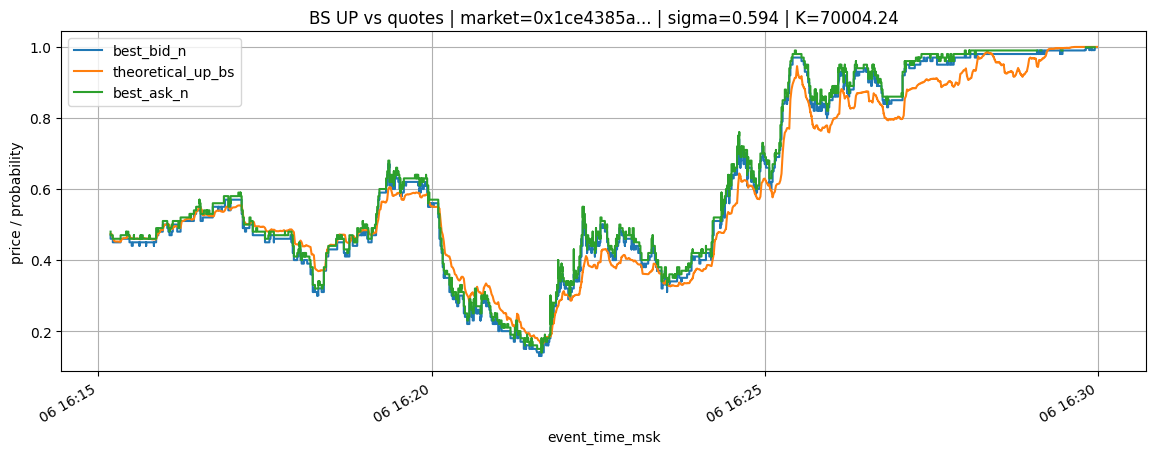

,event_time_msk,event_ts_ms,best_bid_n,best_ask_n,spot_value,price_to_beat,sigma,theoretical_up_bs,buy_edge_bs,sell_edge_bs,max_cross_side_edge_bs
201787,2026-03-06 16:29:58,1772803798942,0.999,NaN,70081.394142,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201788,2026-03-06 16:29:58,1772803798955,0.999,NaN,70081.394142,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201789,2026-03-06 16:29:58,1772803798970,0.999,NaN,70081.394142,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201790,2026-03-06 16:29:59,1772803799013,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201791,2026-03-06 16:29:59,1772803799017,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201792,2026-03-06 16:29:59,1772803799022,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201793,2026-03-06 16:29:59,1772803799052,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201794,2026-03-06 16:29:59,1772803799054,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201795,2026-03-06 16:29:59,1772803799062,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001
201796,2026-03-06 16:29:59,1772803799065,0.999,NaN,70076.569890,70004.236534,0.594,1.0,NaN,-0.001,-0.001


In [8]:
import os
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x1ce4385a64ce0c714e37536f21f33109f7da557adb495a0662465d3ded98d81f"  # conditionId
sigma = 0.594
r = 0.0
min_total_size = 50.0
duration_min = 15
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")
GAMMA_API = "https://gamma-api.polymarket.com"

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
    "cum_bid_size_at_best_bid_n": cb,
    "cum_ask_size_at_best_ask_n": ca,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
                "cum_bid_size_at_best_bid_n": cb,
                "cum_ask_size_at_best_ask_n": ca,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
            "cum_bid_size_at_best_bid_n": cb,
            "cum_ask_size_at_best_ask_n": ca,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) price_to_beat = первый spot value нового рынка
# =========================
resp = requests.get(
    f"{GAMMA_API}/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
)
resp.raise_for_status()
payload = resp.json()
markets = payload if isinstance(payload, list) else payload.get("data", [])

if not markets:
    raise ValueError("Gamma API не вернул рынок по condition_id")

g = markets[0]
end_raw = g.get("endDate") or g.get("end_date") or g.get("endTime") or g.get("end_time")
if not end_raw:
    raise ValueError("Не найден endDate/endTime в Gamma")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
price_to_beat_mode = "first_at_or_after_start"

if not p2b:
    p2b_sql_fb = f"""
    SELECT event_ts_ms, value
    FROM {DB}.{SPOT_TABLE}
    WHERE symbol = {q(symbol.lower())}
      AND event_ts_ms < {start_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """
    p2b = c.query(p2b_sql_fb).result_rows
    price_to_beat_mode = "last_before_start_fallback"

if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT ДЛЯ merge_asof
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {max(0, int(df_quotes['event_ts_ms'].min()) - 120000)}
  AND event_ts_ms <= {max(end_ts_ms, int(df_quotes['event_ts_ms'].max()))}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot в выбранном окне")

# =========================
# 4) BLACK-SCHOLES (digital UP): P(UP)=N(d2)
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bs["event_time_msk"] = pd.to_datetime(df_bs["event_time_msk"])
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = price_to_beat
df_bs["sigma"] = sigma
df_bs["r"] = r
df_bs["market_end_ts_ms"] = end_ts_ms
df_bs["time_to_expiry_sec"] = ((df_bs["market_end_ts_ms"] - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau_years"] = df_bs["time_to_expiry_sec"] / (365.0 * 24.0 * 60.0 * 60.0)

df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= price_to_beat, 1.0, 0.0)

mask = (df_bs["tau_years"] > 0) & (df_bs["spot_value"] > 0)
d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / price_to_beat)
    + (r - 0.5 * sigma * sigma) * df_bs.loc[mask, "tau_years"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau_years"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(norm_cdf).astype(float)
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

# Отклонения
df_bs["mid_n"] = (df_bs["best_bid_n"] + df_bs["best_ask_n"]) / 2.0
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)
df_bs["inside_spread_bs"] = (
    (df_bs["theoretical_up_bs"] >= df_bs["best_bid_n"])
    & (df_bs["theoretical_up_bs"] <= df_bs["best_ask_n"])
).astype(int)

# Метрики
metrics = {
    "rows": int(len(df_bs)),
    "sigma": float(sigma),
    "price_to_beat": float(price_to_beat),
    "price_to_beat_mode": price_to_beat_mode,
    "inside_spread_rate": float(df_bs["inside_spread_bs"].mean()),
    "mae_to_mid": float((df_bs["theoretical_up_bs"] - df_bs["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bs["theoretical_up_bs"] - df_bs["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bs["theoretical_up_bs"] > df_bs["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bs["theoretical_up_bs"] < df_bs["best_bid_n"]).mean()),
    "mean_buy_edge": float(df_bs["buy_edge_bs"].mean()),
    "mean_sell_edge": float(df_bs["sell_edge_bs"].mean()),
    "max_cross_side_edge": float(df_bs["max_cross_side_edge_bs"].max()),
    "p95_cross_side_edge": float(df_bs["max_cross_side_edge_bs"].quantile(0.95)),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

# =========================
# 5) ГРАФИК
# =========================
ax = df_bs.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bs", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"BS UP vs quotes | market={market[:10]}... | sigma={sigma} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bs[[
    "event_time_msk",
    "event_ts_ms",
    "best_bid_n",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "sigma",
    "theoretical_up_bs",
    "buy_edge_bs",
    "sell_edge_bs",
    "max_cross_side_edge_bs"
]].tail(30))


In [9]:
import os

out = df_bs.sort_values("event_ts_ms").reset_index(drop=True).copy()

# Полная таблица
out.to_csv("bs_table_full.csv", index=False)

# Топ-1000 по расхождению (удобно смотреть отдельно)
top = out.reindex(out["max_cross_side_edge_bs"].abs().sort_values(ascending=False).index).head(1000)
top.to_csv("bs_table_top_1000_deviation.csv", index=False)

print("Сохранено:")
print(os.path.abspath("bs_table_full.csv"))
print(os.path.abspath("bs_table_top_1000_deviation.csv"))


Сохранено:
/Users/roman230901gmail.com/Desktop/project/bs_table_full.csv
/Users/roman230901gmail.com/Desktop/project/bs_table_top_1000_deviation.csv


In [10]:
import os
import matplotlib.pyplot as plt

fig = ax.get_figure()
fig.tight_layout()

fig.savefig("bs_graph.png", dpi=220, bbox_inches="tight")
fig.savefig("bs_graph.svg", bbox_inches="tight")  # удобно увеличивать без потери качества

print(os.path.abspath("bs_graph.png"))
print(os.path.abspath("bs_graph.svg"))


/Users/roman230901gmail.com/Desktop/project/bs_graph.png
/Users/roman230901gmail.com/Desktop/project/bs_graph.svg


,value
rows,201817
sigma,0.82
price_to_beat,70004.236534
price_to_beat_mode,first_at_or_after_start
inside_spread_rate,0.091657
mae_to_mid,0.070281
rmse_to_mid,0.086365
pct_theory_above_ask,0.368344
pct_theory_below_bid,0.538285
mean_buy_edge,-0.032391


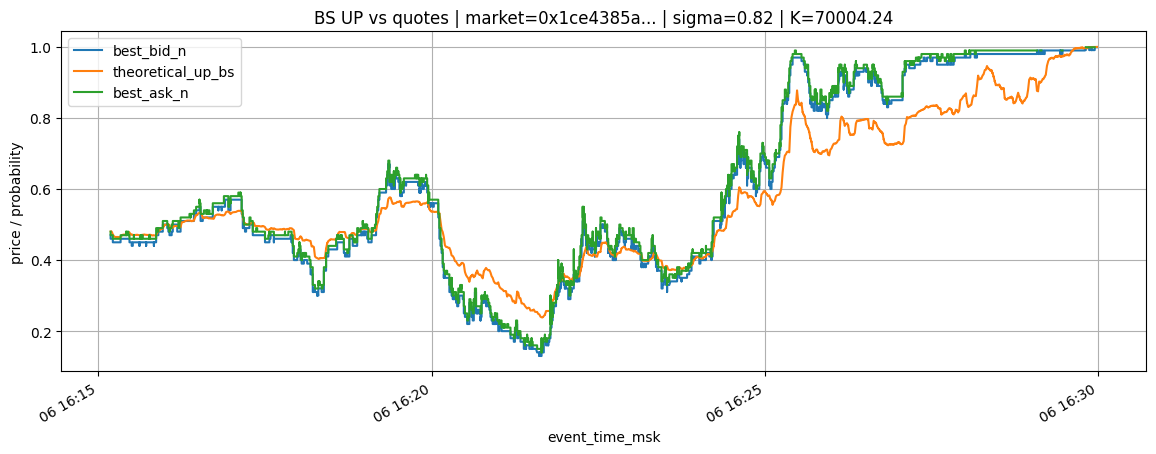

,event_time_msk,event_ts_ms,best_bid_n,best_ask_n,spot_value,price_to_beat,sigma,theoretical_up_bs,buy_edge_bs,sell_edge_bs,max_cross_side_edge_bs
201787,2026-03-06 16:29:58,1772803798942,0.999,NaN,70081.394142,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201788,2026-03-06 16:29:58,1772803798955,0.999,NaN,70081.394142,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201789,2026-03-06 16:29:58,1772803798970,0.999,NaN,70081.394142,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201790,2026-03-06 16:29:59,1772803799013,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201791,2026-03-06 16:29:59,1772803799017,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201792,2026-03-06 16:29:59,1772803799022,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201793,2026-03-06 16:29:59,1772803799052,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201794,2026-03-06 16:29:59,1772803799054,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201795,2026-03-06 16:29:59,1772803799062,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001
201796,2026-03-06 16:29:59,1772803799065,0.999,NaN,70076.569890,70004.236534,0.82,1.0,NaN,-0.001,-0.001


In [11]:
import os
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x1ce4385a64ce0c714e37536f21f33109f7da557adb495a0662465d3ded98d81f"  # conditionId
sigma = 0.82
r = 0.0
min_total_size = 50.0
duration_min = 15
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")
GAMMA_API = "https://gamma-api.polymarket.com"

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
    "cum_bid_size_at_best_bid_n": cb,
    "cum_ask_size_at_best_ask_n": ca,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
                "cum_bid_size_at_best_bid_n": cb,
                "cum_ask_size_at_best_ask_n": ca,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
            "cum_bid_size_at_best_bid_n": cb,
            "cum_ask_size_at_best_ask_n": ca,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) price_to_beat = первый spot value нового рынка
# =========================
resp = requests.get(
    f"{GAMMA_API}/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
)
resp.raise_for_status()
payload = resp.json()
markets = payload if isinstance(payload, list) else payload.get("data", [])

if not markets:
    raise ValueError("Gamma API не вернул рынок по condition_id")

g = markets[0]
end_raw = g.get("endDate") or g.get("end_date") or g.get("endTime") or g.get("end_time")
if not end_raw:
    raise ValueError("Не найден endDate/endTime в Gamma")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
price_to_beat_mode = "first_at_or_after_start"

if not p2b:
    p2b_sql_fb = f"""
    SELECT event_ts_ms, value
    FROM {DB}.{SPOT_TABLE}
    WHERE symbol = {q(symbol.lower())}
      AND event_ts_ms < {start_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """
    p2b = c.query(p2b_sql_fb).result_rows
    price_to_beat_mode = "last_before_start_fallback"

if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT ДЛЯ merge_asof
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {max(0, int(df_quotes['event_ts_ms'].min()) - 120000)}
  AND event_ts_ms <= {max(end_ts_ms, int(df_quotes['event_ts_ms'].max()))}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot в выбранном окне")

# =========================
# 4) BLACK-SCHOLES (digital UP): P(UP)=N(d2)
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bs["event_time_msk"] = pd.to_datetime(df_bs["event_time_msk"])
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = price_to_beat
df_bs["sigma"] = sigma
df_bs["r"] = r
df_bs["market_end_ts_ms"] = end_ts_ms
df_bs["time_to_expiry_sec"] = ((df_bs["market_end_ts_ms"] - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau_years"] = df_bs["time_to_expiry_sec"] / (365.0 * 24.0 * 60.0 * 60.0)

df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= price_to_beat, 1.0, 0.0)

mask = (df_bs["tau_years"] > 0) & (df_bs["spot_value"] > 0)
d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / price_to_beat)
    + (r - 0.5 * sigma * sigma) * df_bs.loc[mask, "tau_years"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau_years"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(norm_cdf).astype(float)
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

# Отклонения
df_bs["mid_n"] = (df_bs["best_bid_n"] + df_bs["best_ask_n"]) / 2.0
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)
df_bs["inside_spread_bs"] = (
    (df_bs["theoretical_up_bs"] >= df_bs["best_bid_n"])
    & (df_bs["theoretical_up_bs"] <= df_bs["best_ask_n"])
).astype(int)

# Метрики
metrics = {
    "rows": int(len(df_bs)),
    "sigma": float(sigma),
    "price_to_beat": float(price_to_beat),
    "price_to_beat_mode": price_to_beat_mode,
    "inside_spread_rate": float(df_bs["inside_spread_bs"].mean()),
    "mae_to_mid": float((df_bs["theoretical_up_bs"] - df_bs["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bs["theoretical_up_bs"] - df_bs["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bs["theoretical_up_bs"] > df_bs["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bs["theoretical_up_bs"] < df_bs["best_bid_n"]).mean()),
    "mean_buy_edge": float(df_bs["buy_edge_bs"].mean()),
    "mean_sell_edge": float(df_bs["sell_edge_bs"].mean()),
    "max_cross_side_edge": float(df_bs["max_cross_side_edge_bs"].max()),
    "p95_cross_side_edge": float(df_bs["max_cross_side_edge_bs"].quantile(0.95)),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

# =========================
# 5) ГРАФИК
# =========================
ax = df_bs.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bs", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"BS UP vs quotes | market={market[:10]}... | sigma={sigma} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bs[[
    "event_time_msk",
    "event_ts_ms",
    "best_bid_n",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "sigma",
    "theoretical_up_bs",
    "buy_edge_bs",
    "sell_edge_bs",
    "max_cross_side_edge_bs"
]].tail(30))